In [1]:
import pandas as pd

df = pd.read_csv('Full-Data.csv')
DROP_COLS = ["LATITUDE", "LONGITUD"]

# drop them if they exist
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

/var/folders/f9/23c1jfhx0435n0xc7vtjd6g80000gp/T/ipykernel_13490/112950527.py:3: DtypeWarning: Columns (20,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Full-Data.csv')


In [2]:
severity_mapping = {
    "Fatal Injury (K)": "Fatal Injury",
    "Died Prior to Crash*": "Fatal Injury",
    "Suspected Minor Injury (B)": "Non-Fatal",
    "Suspected Serious Injury (A)": "Non-Fatal",
    "Possible Injury (C)": "Non-Fatal",
    "Injured, Severity Unknown": "Non-Fatal",
    "No Apparent Injury (O)": "Non-Fatal"
}

df["injury_severity_classes"] = df["INJ_SEVNAME"].map(severity_mapping)

In [3]:
df_model= df
class_mapping = {
    "Non-Fatal": 0,
    "Fatal Injury": 1
}

# Create numeric target
df_model["injury_severity_class"] = df_model["injury_severity_classes"].map(class_mapping)

In [4]:
# Target
y = df_model["injury_severity_class"]

# Features = all columns except the target(s)
X = df_model.drop(columns=["injury_severity_classes", "INJ_SEVNAME","injury_severity_class"])

In [5]:
df_model

,YEAR,STATENAME,ST_CASE,MONTHNAME,HOUR,RUR_URBNAME,FUNC_SYSNAME,HARM_EVNAME,MAN_COLLNAME,ROLLOVERNAME,...,AIR_BAGNAME,EJECTIONNAME,DRINKINGNAME,DRUG_DETNAME,ROUTENAME,RD_OWNERNAME,LGT_CONDNAME,WEATHER1NAME,injury_severity_classes,injury_severity_class
0,2015,Alabama,10001,January,2,Rural,Principal Arterial - Other,Embankment,Not a Collision with Motor Vehicle In-Transport,No Rollover,...,Deployed- Front,Not Ejected,Unknown (Police Reported),Not Reported,State Highway,State Highway Agency,Dark - Not Lighted,Clear,Fatal Injury,1.0
1,2015,Alabama,10002,January,22,Rural,Interstate,Ditch,Not a Collision with Motor Vehicle In-Transport,"Rollover, Tripped by Object/Vehicle",...,Not Deployed,Totally Ejected,No (Alcohol Not Involved),Not Reported,Interstate,State Highway Agency,Dark - Not Lighted,Cloudy,Fatal Injury,1.0
2,2015,Alabama,10003,January,1,Rural,Principal Arterial - Other,Tree (Standing Only),Not a Collision with Motor Vehicle In-Transport,"Rollover, Tripped by Object/Vehicle",...,Deployed- Front,Not Ejected,Yes (Alcohol Involved),Not Reported,U.S. Highway,State Highway Agency,Dark - Not Lighted,Clear,Fatal Injury,1.0
3,2015,Alabama,10003,January,1,Rural,Principal Arterial - Other,Tree (Standing Only),Not a Collision with Motor Vehicle In-Transport,"Rollover, Tripped by Object/Vehicle",...,Deployed- Front,Not Ejected,Not Reported,Not Reported,U.S. Highway,State Highway Agency,Dark - Not Lighted,Clear,NaN,NaN
4,2015,Alabama,10004,January,0,Rural,Minor Arterial,Mail Box,Not a Collision with Motor Vehicle In-Transport,No Rollover,...,Not Deployed,Not Ejected,Yes (Alcohol Involved),Not Reported,State Highway,State Highway Agency,Dark - Not Lighted,Cloudy,Fatal Injury,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
793180,2023,Wyoming,560120,December,8,Rural,Other Principal Arterial,Motor Vehicle In-Transport,Angle,No Rollover,...,Not Deployed,Not Ejected,Not Reported,NaN,U.S. Highway,State Highway Agency,Daylight,NaN,Non-Fatal,0.0
793181,2023,Wyoming,560120,December,8,Rural,Other Principal Arterial,Motor Vehicle In-Transport,Angle,No Rollover,...,Not Deployed,Not Ejected,Not Reported,NaN,U.S. Highway,State Highway Agency,Daylight,NaN,Non-Fatal,0.0
793182,2023,Wyoming,560120,December,8,Rural,Other Principal Arterial,Motor Vehicle In-Transport,Angle,No Rollover,...,"Deployed- Side (door, seatback)",Totally Ejected,Not Reported,NaN,U.S. Highway,State Highway Agency,Daylight,NaN,Fatal Injury,1.0
793183,2023,Wyoming,560120,December,8,Rural,Other Principal Arterial,Motor Vehicle In-Transport,Angle,No Rollover,...,Deployed- Front,Not Ejected,No (Alcohol Not Involved),NaN,U.S. Highway,State Highway Agency,Daylight,NaN,Non-Fatal,0.0


In [6]:
df=df_model

In [7]:
# ============================================================
# Replace NaN in DRUG_DETNAME with "Not Reported"
# ============================================================

import pandas as pd

# Replace NaN or missing with "Not Reported"
df["DRUG_DETNAME"] = df["DRUG_DETNAME"].fillna("Not Reported")
df["WEATHER1NAME"] = df["WEATHER1NAME"].fillna("Not Reported")

# ------------------------------------------------------------
# Optional: verify replacement
# ------------------------------------------------------------
value_counts = (
    df["DRUG_DETNAME"]
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={"index": "DRUG_DETNAME", "DRUG_DETNAME": "Frequency"})
)
value_counts["Percent"] = (value_counts["Frequency"] / len(df) * 100).round(2)

print("Updated Value Distribution for DRUG_DETNAME:")
print(value_counts.to_string(index=False))


Updated Value Distribution for DRUG_DETNAME:
                                             DRUG_DETNAME  Frequency  Percent
                                             Not Reported     709608    89.46
                           Evidential Test (Blood, Urine)      55675     7.02
                                                    Other      18208     2.30
                                Observed Behavior or SFST       5437     0.69
                                               Behavioral       2064     0.26
             Drug Recognition Expert (or Evaluator) (DRE)       1021     0.13
Drug Recognition Expert (or Evaluator)(DRE) determination        899     0.11
          Drug Recognition Technician (DRT) determination        273     0.03


In [8]:
# ============================================================
# Replace NaN in ROLLOVERNAME with "Not Applicable"
# ============================================================

import pandas as pd

# Replace missing values with "Not Applicable"
df["ROLLOVERNAME"] = df["ROLLOVERNAME"].fillna("Not Applicable")

# ------------------------------------------------------------
# Optional verification
# ------------------------------------------------------------
rollover_summary = (
    df["ROLLOVERNAME"]
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={"index": "ROLLOVERNAME", "ROLLOVERNAME": "Frequency"})
)
rollover_summary["Percent"] = (rollover_summary["Frequency"] / len(df) * 100).round(2)

print("Updated Value Distribution for ROLLOVERNAME:")
print(rollover_summary.to_string(index=False))


Updated Value Distribution for ROLLOVERNAME:
                       ROLLOVERNAME  Frequency  Percent
                        No Rollover     583527    73.57
                     Not Applicable      87984    11.09
Rollover, Tripped by Object/Vehicle      74899     9.44
                           Rollover      26693     3.37
                Rollover, Untripped      13042     1.64
             Rollover, Unknown Type       7040     0.89


In [9]:
# ============================================================
# Replace NaN in FIRE_EXPNAME with "No or Not Reported"
# ============================================================

import pandas as pd

# Replace missing values with "No or Not Reported"
df["FIRE_EXPNAME"] = df["FIRE_EXPNAME"].fillna("No or Not Reported")

# ------------------------------------------------------------
# Optional verification
# ------------------------------------------------------------
fire_summary = (
    df["FIRE_EXPNAME"]
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={"index": "FIRE_EXPNAME", "FIRE_EXPNAME": "Frequency"})
)
fire_summary["Percent"] = (fire_summary["Frequency"] / len(df) * 100).round(2)

print("Updated Value Distribution for FIRE_EXPNAME:")
print(fire_summary.to_string(index=False))


Updated Value Distribution for FIRE_EXPNAME:
      FIRE_EXPNAME  Frequency  Percent
No or Not Reported     768979    96.95
               Yes      24206     3.05


In [10]:
df = df.dropna().copy()


In [11]:
df

,YEAR,STATENAME,ST_CASE,MONTHNAME,HOUR,RUR_URBNAME,FUNC_SYSNAME,HARM_EVNAME,MAN_COLLNAME,ROLLOVERNAME,...,AIR_BAGNAME,EJECTIONNAME,DRINKINGNAME,DRUG_DETNAME,ROUTENAME,RD_OWNERNAME,LGT_CONDNAME,WEATHER1NAME,injury_severity_classes,injury_severity_class
0,2015,Alabama,10001,January,2,Rural,Principal Arterial - Other,Embankment,Not a Collision with Motor Vehicle In-Transport,No Rollover,...,Deployed- Front,Not Ejected,Unknown (Police Reported),Not Reported,State Highway,State Highway Agency,Dark - Not Lighted,Clear,Fatal Injury,1.0
1,2015,Alabama,10002,January,22,Rural,Interstate,Ditch,Not a Collision with Motor Vehicle In-Transport,"Rollover, Tripped by Object/Vehicle",...,Not Deployed,Totally Ejected,No (Alcohol Not Involved),Not Reported,Interstate,State Highway Agency,Dark - Not Lighted,Cloudy,Fatal Injury,1.0
2,2015,Alabama,10003,January,1,Rural,Principal Arterial - Other,Tree (Standing Only),Not a Collision with Motor Vehicle In-Transport,"Rollover, Tripped by Object/Vehicle",...,Deployed- Front,Not Ejected,Yes (Alcohol Involved),Not Reported,U.S. Highway,State Highway Agency,Dark - Not Lighted,Clear,Fatal Injury,1.0
4,2015,Alabama,10004,January,0,Rural,Minor Arterial,Mail Box,Not a Collision with Motor Vehicle In-Transport,No Rollover,...,Not Deployed,Not Ejected,Yes (Alcohol Involved),Not Reported,State Highway,State Highway Agency,Dark - Not Lighted,Cloudy,Fatal Injury,1.0
5,2015,Alabama,10005,January,7,Urban,Principal Arterial - Other,Motor Vehicle In-Transport,Angle,"Rollover, Tripped by Object/Vehicle",...,Not Deployed,Not Ejected,No (Alcohol Not Involved),Not Reported,U.S. Highway,State Highway Agency,Daylight,Clear,Fatal Injury,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
793180,2023,Wyoming,560120,December,8,Rural,Other Principal Arterial,Motor Vehicle In-Transport,Angle,No Rollover,...,Not Deployed,Not Ejected,Not Reported,Not Reported,U.S. Highway,State Highway Agency,Daylight,Not Reported,Non-Fatal,0.0
793181,2023,Wyoming,560120,December,8,Rural,Other Principal Arterial,Motor Vehicle In-Transport,Angle,No Rollover,...,Not Deployed,Not Ejected,Not Reported,Not Reported,U.S. Highway,State Highway Agency,Daylight,Not Reported,Non-Fatal,0.0
793182,2023,Wyoming,560120,December,8,Rural,Other Principal Arterial,Motor Vehicle In-Transport,Angle,No Rollover,...,"Deployed- Side (door, seatback)",Totally Ejected,Not Reported,Not Reported,U.S. Highway,State Highway Agency,Daylight,Not Reported,Fatal Injury,1.0
793183,2023,Wyoming,560120,December,8,Rural,Other Principal Arterial,Motor Vehicle In-Transport,Angle,No Rollover,...,Deployed- Front,Not Ejected,No (Alcohol Not Involved),Not Reported,U.S. Highway,State Highway Agency,Daylight,Not Reported,Non-Fatal,0.0


Missing Value Summary (Total Rows = 745,326)
                 Column  Missing_Count  Missing_%
                   YEAR              0        0.0
            INJ_SEVNAME              0        0.0
injury_severity_classes              0        0.0
           WEATHER1NAME              0        0.0
           LGT_CONDNAME              0        0.0
           RD_OWNERNAME              0        0.0
              ROUTENAME              0        0.0
           DRUG_DETNAME              0        0.0
           DRINKINGNAME              0        0.0
           EJECTIONNAME              0        0.0
            AIR_BAGNAME              0        0.0
           REST_USENAME              0        0.0
           SEAT_POSNAME              0        0.0
            PER_TYPNAME              0        0.0
              STATENAME              0        0.0
                SEXNAME              0        0.0
                    AGE              0        0.0
           FIRE_EXPNAME              0        0.0
     

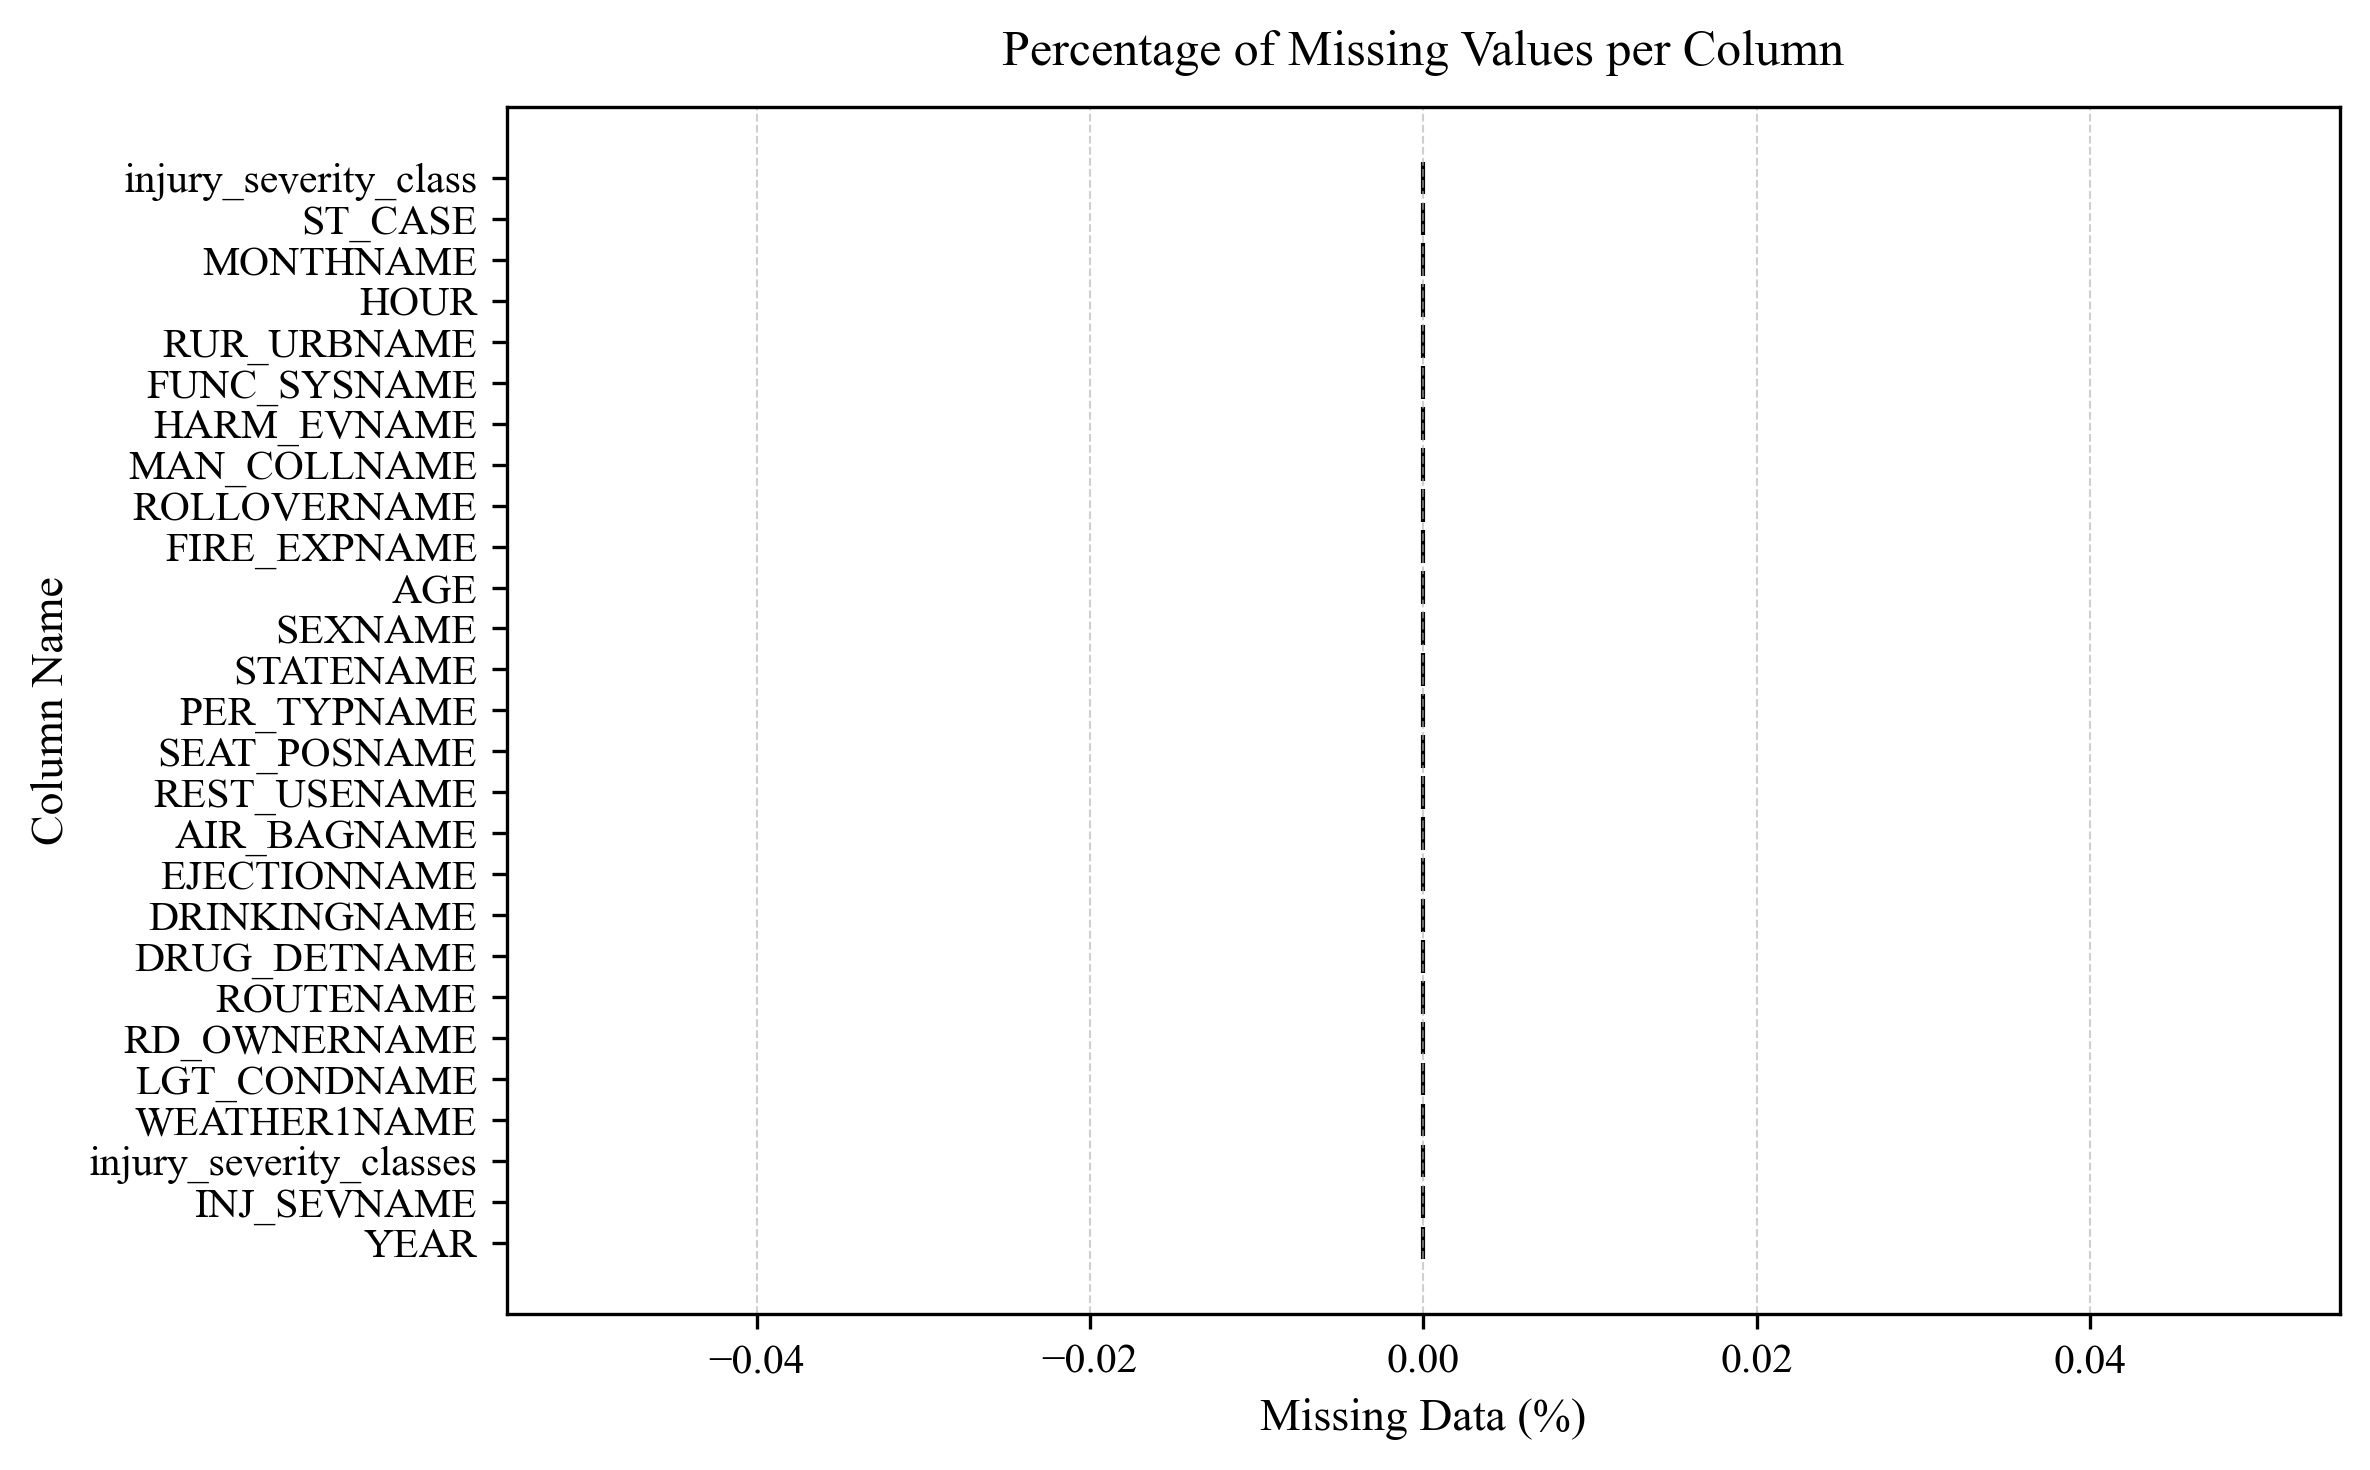

In [12]:
# ============================================================
# Missing Value Summary (before dropping NaNs)
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Count missing values per column
# ------------------------------------------------------------
missing_summary = (
    df.isna()
      .sum()
      .reset_index()
      .rename(columns={"index": "Column", 0: "Missing_Count"})
)

# ------------------------------------------------------------
# 2. Add total rows and percentage
# ------------------------------------------------------------
total_rows = len(df)
missing_summary["Missing_%"] = (missing_summary["Missing_Count"] / total_rows * 100).round(2)

# ------------------------------------------------------------
# 3. Sort by most missing
# ------------------------------------------------------------
missing_summary = missing_summary.sort_values("Missing_Count", ascending=False).reset_index(drop=True)

# ------------------------------------------------------------
# 4. Display clean summary
# ------------------------------------------------------------
print("==========================================================")
print(f"Missing Value Summary (Total Rows = {total_rows:,})")
print("==========================================================")
print(missing_summary.to_string(index=False))
print("==========================================================")

# ------------------------------------------------------------
# 5. Optional: plot missingness visually (journal-style)
# ------------------------------------------------------------
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"
plt.figure(figsize=(8, 5), dpi=300)
plt.barh(
    missing_summary["Column"],
    missing_summary["Missing_%"],
    color="lightgray",
    edgecolor="black"
)
plt.xlabel("Missing Data (%)", fontsize=11)
plt.ylabel("Column Name", fontsize=11)
plt.title("Percentage of Missing Values per Column", fontsize=12, pad=10)
plt.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.savefig("fig_missing_values_overview.png", bbox_inches="tight", dpi=300)
plt.show()


In [13]:
df

,YEAR,STATENAME,ST_CASE,MONTHNAME,HOUR,RUR_URBNAME,FUNC_SYSNAME,HARM_EVNAME,MAN_COLLNAME,ROLLOVERNAME,...,AIR_BAGNAME,EJECTIONNAME,DRINKINGNAME,DRUG_DETNAME,ROUTENAME,RD_OWNERNAME,LGT_CONDNAME,WEATHER1NAME,injury_severity_classes,injury_severity_class
0,2015,Alabama,10001,January,2,Rural,Principal Arterial - Other,Embankment,Not a Collision with Motor Vehicle In-Transport,No Rollover,...,Deployed- Front,Not Ejected,Unknown (Police Reported),Not Reported,State Highway,State Highway Agency,Dark - Not Lighted,Clear,Fatal Injury,1.0
1,2015,Alabama,10002,January,22,Rural,Interstate,Ditch,Not a Collision with Motor Vehicle In-Transport,"Rollover, Tripped by Object/Vehicle",...,Not Deployed,Totally Ejected,No (Alcohol Not Involved),Not Reported,Interstate,State Highway Agency,Dark - Not Lighted,Cloudy,Fatal Injury,1.0
2,2015,Alabama,10003,January,1,Rural,Principal Arterial - Other,Tree (Standing Only),Not a Collision with Motor Vehicle In-Transport,"Rollover, Tripped by Object/Vehicle",...,Deployed- Front,Not Ejected,Yes (Alcohol Involved),Not Reported,U.S. Highway,State Highway Agency,Dark - Not Lighted,Clear,Fatal Injury,1.0
4,2015,Alabama,10004,January,0,Rural,Minor Arterial,Mail Box,Not a Collision with Motor Vehicle In-Transport,No Rollover,...,Not Deployed,Not Ejected,Yes (Alcohol Involved),Not Reported,State Highway,State Highway Agency,Dark - Not Lighted,Cloudy,Fatal Injury,1.0
5,2015,Alabama,10005,January,7,Urban,Principal Arterial - Other,Motor Vehicle In-Transport,Angle,"Rollover, Tripped by Object/Vehicle",...,Not Deployed,Not Ejected,No (Alcohol Not Involved),Not Reported,U.S. Highway,State Highway Agency,Daylight,Clear,Fatal Injury,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
793180,2023,Wyoming,560120,December,8,Rural,Other Principal Arterial,Motor Vehicle In-Transport,Angle,No Rollover,...,Not Deployed,Not Ejected,Not Reported,Not Reported,U.S. Highway,State Highway Agency,Daylight,Not Reported,Non-Fatal,0.0
793181,2023,Wyoming,560120,December,8,Rural,Other Principal Arterial,Motor Vehicle In-Transport,Angle,No Rollover,...,Not Deployed,Not Ejected,Not Reported,Not Reported,U.S. Highway,State Highway Agency,Daylight,Not Reported,Non-Fatal,0.0
793182,2023,Wyoming,560120,December,8,Rural,Other Principal Arterial,Motor Vehicle In-Transport,Angle,No Rollover,...,"Deployed- Side (door, seatback)",Totally Ejected,Not Reported,Not Reported,U.S. Highway,State Highway Agency,Daylight,Not Reported,Fatal Injury,1.0
793183,2023,Wyoming,560120,December,8,Rural,Other Principal Arterial,Motor Vehicle In-Transport,Angle,No Rollover,...,Deployed- Front,Not Ejected,No (Alcohol Not Involved),Not Reported,U.S. Highway,State Highway Agency,Daylight,Not Reported,Non-Fatal,0.0


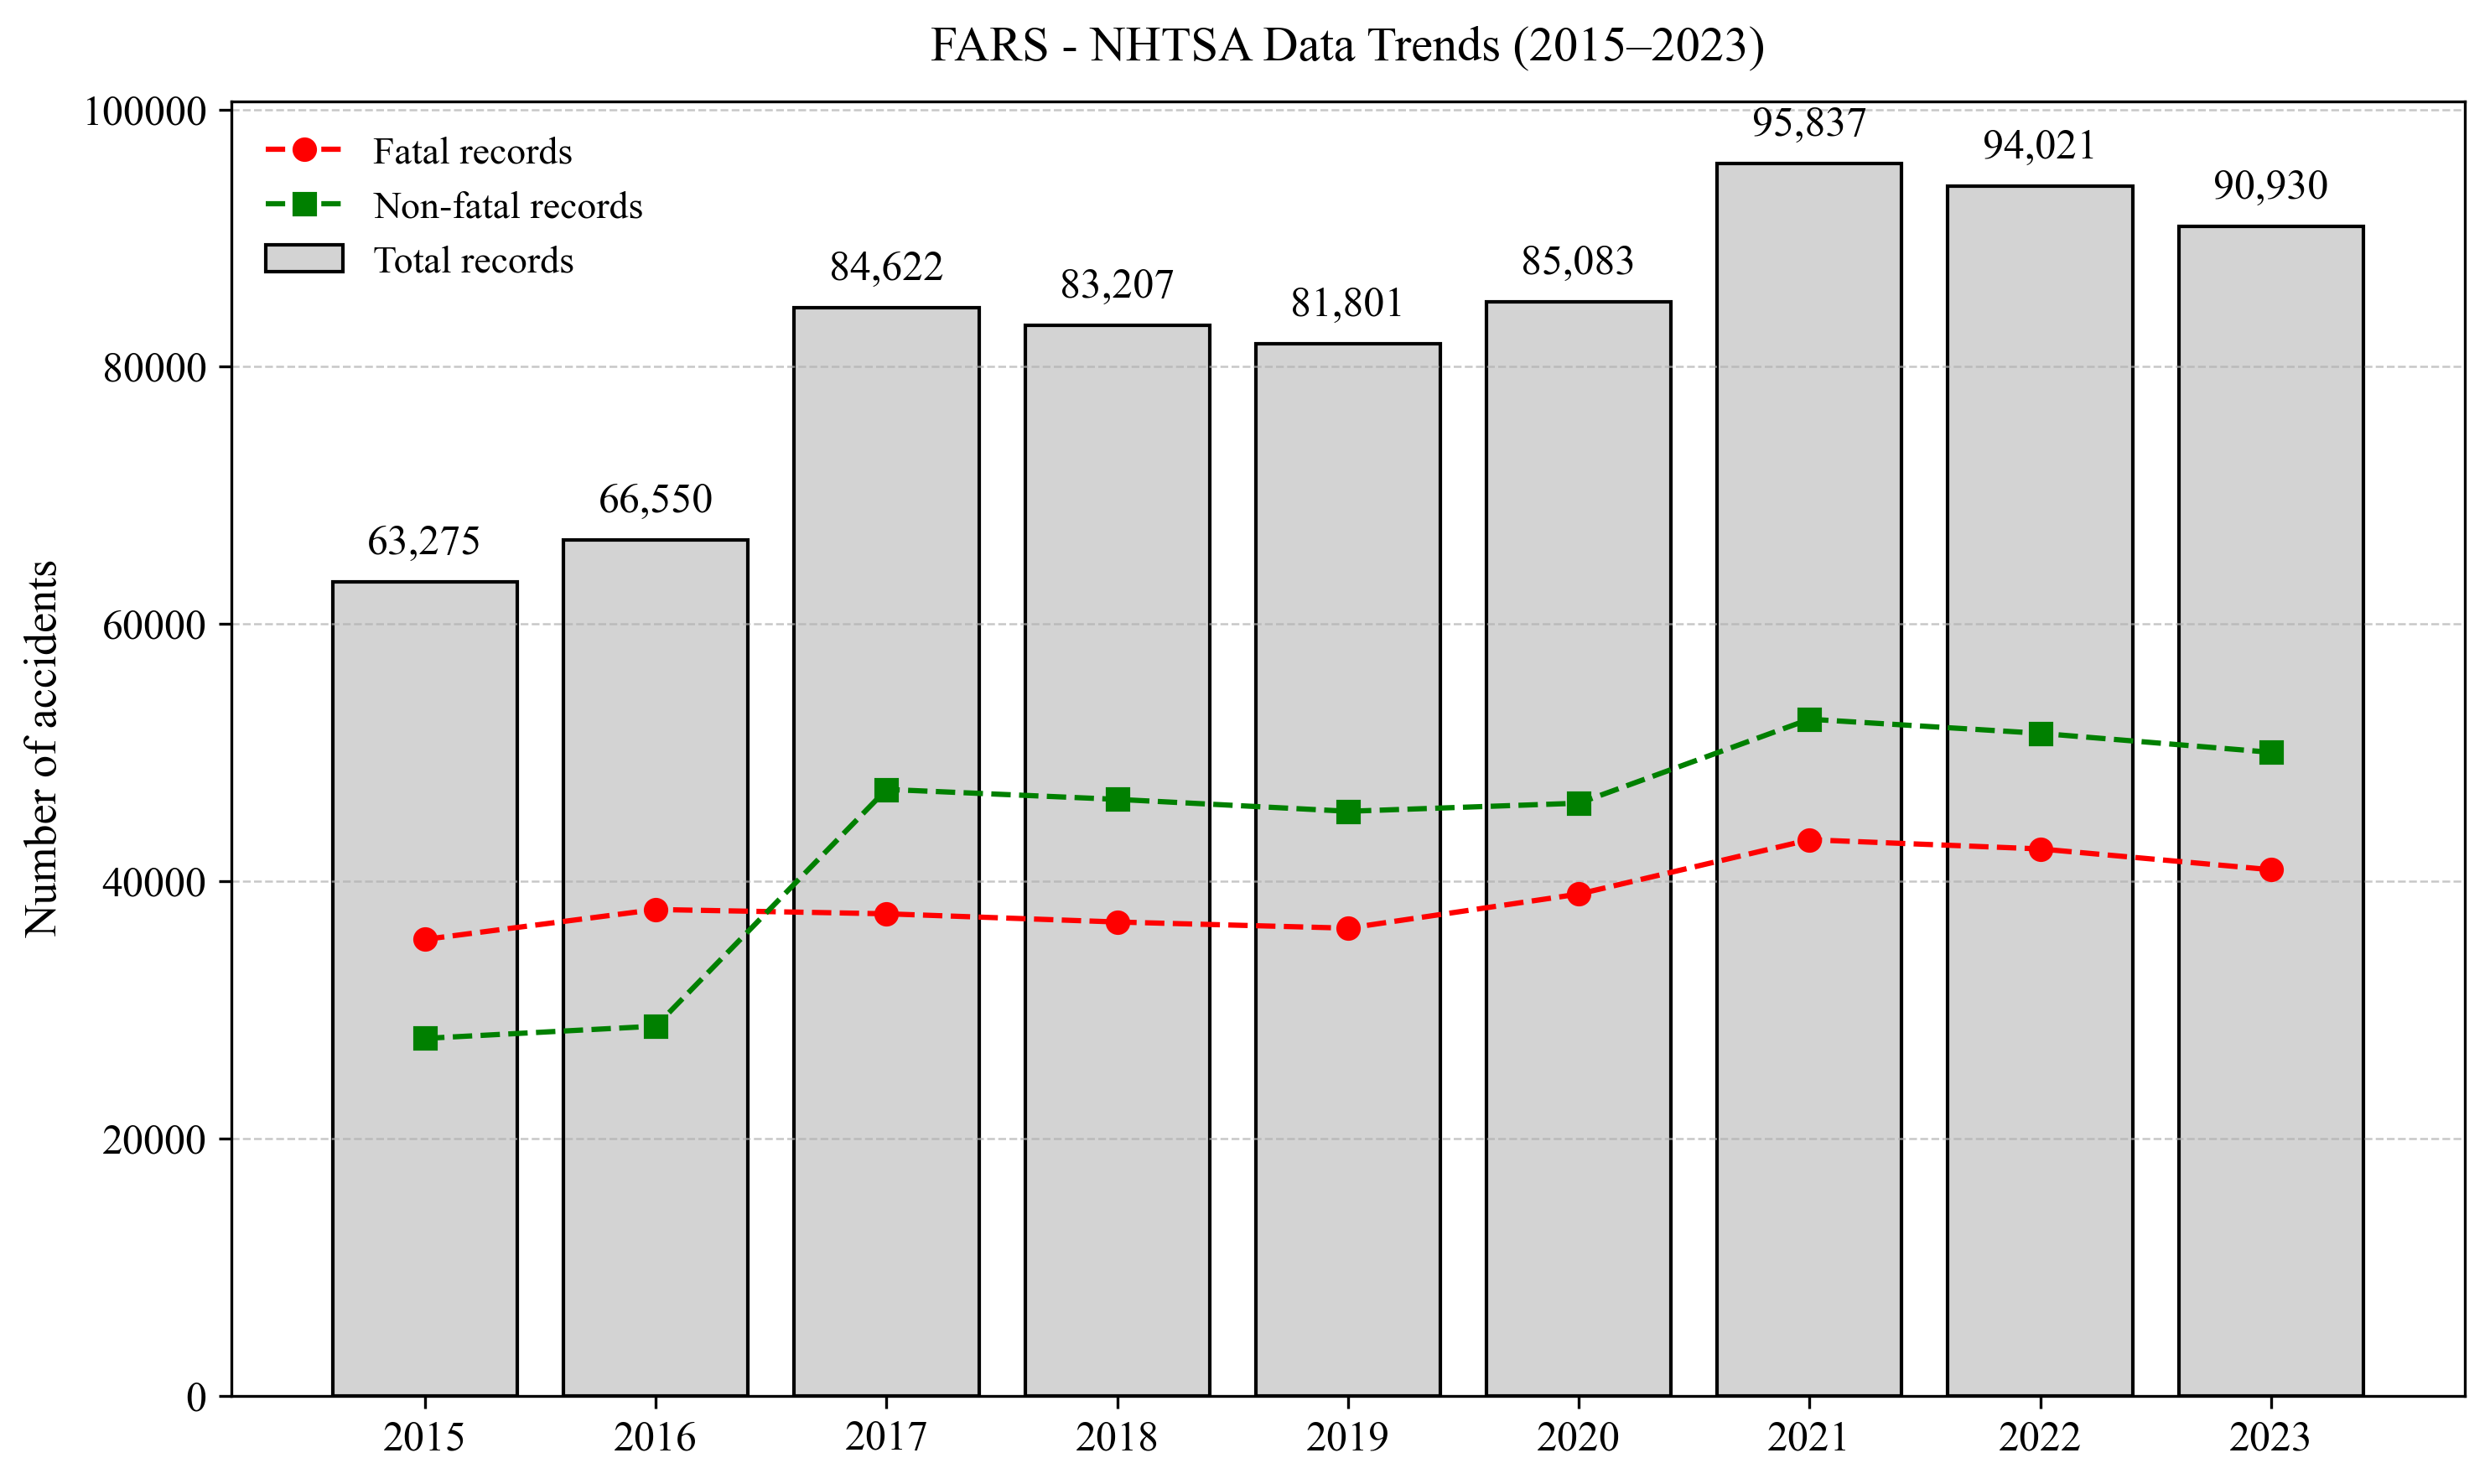

In [14]:
# ============================================================
# Combined Accident Chart (2015–2023)
# Bar: Total accidents per year
# Dotted Lines: Fatal (red) and Non-Fatal (green)
# Designed for journal-quality visualization
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. Aggregate your data by YEAR and injury_severity_classes
# ------------------------------------------------------------
# Ensure YEAR is numeric
df["YEAR"] = pd.to_numeric(df["YEAR"], errors="coerce")
df = df.dropna(subset=["YEAR"]).copy()
df["YEAR"] = df["YEAR"].astype(int)

# Keep only 2015–2023 if needed
df = df[(df["YEAR"] >= 2015) & (df["YEAR"] <= 2023)].copy()

# Create a pivot table counting Fatal and Non-Fatal per year
summary = (
    df.groupby(["YEAR", "injury_severity_classes"])
      .size()
      .unstack(fill_value=0)
      .rename(columns={
          "Fatal Injury": "Fatal",
          "Non-Fatal": "Non-fatal"
      })
)

# Compute total
summary["Total"] = summary.sum(axis=1)

# Sort by year
summary = summary.sort_index()

# ------------------------------------------------------------
# 2. Plot setup
# ------------------------------------------------------------
plt.figure(figsize=(10, 6), dpi=300)

# Bar chart: total accidents per year
plt.bar(summary.index,
        summary["Total"],
        color="lightgray",
        edgecolor="black",
        label="Total records")

# Dotted line: Fatal accidents
plt.plot(summary.index,
         summary["Fatal"],
         color="red",
         linestyle="--",
         marker="o",
         linewidth=1.5,
         label="Fatal records")

# Dotted line: Non-Fatal accidents
plt.plot(summary.index,
         summary["Non-fatal"],
         color="green",
         linestyle="--",
         marker="s",
         linewidth=1.5,
         label="Non-fatal records")

# ------------------------------------------------------------
# 3. Labels, title, legend, and annotations
# ------------------------------------------------------------
plt.ylabel("Number of accidents", fontsize=13)
plt.title("FARS - NHTSA Data Trends (2015–2023)",
          fontsize=14, pad=12)

plt.xticks(summary.index, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(frameon=False, fontsize=11, loc="upper left")

# Add total labels above bars
ymax = summary["Total"].max()
for x, total in zip(summary.index, summary["Total"]):
    plt.text(x, total + ymax * 0.015,
             f"{int(total):,}",
             ha="center", va="bottom", fontsize=12)

# ------------------------------------------------------------
# 4. Export figure
# ------------------------------------------------------------
plt.tight_layout()
plt.savefig("fig_accident_total_with_fatal_nonfatal_lines.png",
            bbox_inches="tight", dpi=300)
plt.show()


In [15]:
# ============================================================
# US Accident Counts by State (All Years Combined)
# - Input df columns: STATENAME, YEAR, injury_severity_classes
# - Output: Choropleth map of counts per state (SVG & PNG)
# - Dependencies: plotly>=5.0, kaleido (for static export)
#   pip install plotly kaleido
# ============================================================

import pandas as pd
import plotly.express as px

# -------------------------------
# 1) Aggregate counts per state
# -------------------------------
# Keep all years together (no filtering by YEAR)
state_counts = (
    df.groupby("STATENAME", dropna=False)
      .size()
      .reset_index(name="count")
)

# -------------------------------
# 2) Map full state names -> USPS codes
# (Plotly's USA choropleth requires 2-letter codes)
# -------------------------------
name_to_code = {
    "Alabama":"AL","Alaska":"AK","Arizona":"AZ","Arkansas":"AR","California":"CA","Colorado":"CO",
    "Connecticut":"CT","Delaware":"DE","District of Columbia":"DC","Florida":"FL","Georgia":"GA",
    "Hawaii":"HI","Idaho":"ID","Illinois":"IL","Indiana":"IN","Iowa":"IA","Kansas":"KS",
    "Kentucky":"KY","Louisiana":"LA","Maine":"ME","Maryland":"MD","Massachusetts":"MA","Michigan":"MI",
    "Minnesota":"MN","Mississippi":"MS","Missouri":"MO","Montana":"MT","Nebraska":"NE","Nevada":"NV",
    "New Hampshire":"NH","New Jersey":"NJ","New Mexico":"NM","New York":"NY","North Carolina":"NC",
    "North Dakota":"ND","Ohio":"OH","Oklahoma":"OK","Oregon":"OR","Pennsylvania":"PA","Rhode Island":"RI",
    "South Carolina":"SC","South Dakota":"SD","Tennessee":"TN","Texas":"TX","Utah":"UT","Vermont":"VT",
    "Virginia":"VA","Washington":"WA","West Virginia":"WV","Wisconsin":"WI","Wyoming":"WY",
    # If your data include territories, add them here with their USPS codes
}

state_counts["state_code"] = state_counts["STATENAME"].map(name_to_code)

# Warn / drop rows that didn't map
unmapped = state_counts[state_counts["state_code"].isna()]
if not unmapped.empty:
    print("WARNING: These STATENAME values did not map to USPS codes and will be excluded:")
    print(unmapped["STATENAME"].unique())

state_counts = state_counts.dropna(subset=["state_code"]).copy()

# -------------------------------
# 3) Choropleth (clean journal style)
# -------------------------------
fig = px.choropleth(
    state_counts,
    locations="state_code",
    locationmode="USA-states",
    color="count",
    scope="usa",
    color_continuous_scale="Reds",  # perceptually uniform; print-friendly
    labels={"count": "Accident count"},
)

# Layout polish: neutral margins, serif font, thin borders
fig.update_layout(
    title_text="Accident Counts by State (All Years Combined)",
    title_x=0.5,
    margin=dict(l=10, r=10, t=50, b=10),
    coloraxis_colorbar=dict(title="Count", ticks="outside"),
    font=dict(family="Times New Roman", size=14),
)
fig.update_traces(marker_line_color="white", marker_line_width=0.5)

# -------------------------------
# 4) Save static exports (vector + PNG)
# -------------------------------
fig.write_image("fig_us_accidents_by_state.svg")   # vector for journals
fig.write_image("fig_us_accidents_by_state.png", scale=3)  # ~300 DPI PNG

# Optional: show interactively in notebooks
# fig.show()

# -------------------------------
# 5) (Optional) Ranked table / bar for appendix
# -------------------------------
ranked = state_counts.sort_values("count", ascending=False)
print(ranked.head(10))  # quick peek at top 10

# If you also want a clean bar chart (appendix / SI):
# import matplotlib.pyplot as plt
# plt.figure(figsize=(8, 10), dpi=300)
# ax = plt.barh(ranked["state_code"], ranked["count"])
# plt.gca().invert_yaxis()
# plt.xlabel("Accident count")
# plt.title("Accident Counts by State (All Years)")
# plt.tight_layout()
# plt.savefig("fig_us_accidents_by_state_bar.png", dpi=300, bbox_inches="tight")
# plt.show()


         STATENAME  count state_code
4       California  78816         CA
43           Texas  76761         TX
9          Florida  67508         FL
10         Georgia  31057         GA
33  North Carolina  28400         NC
35            Ohio  22850         OH
38    Pennsylvania  22193         PA
13        Illinois  21853         IL
42       Tennessee  21714         TN
2          Arizona  21392         AZ


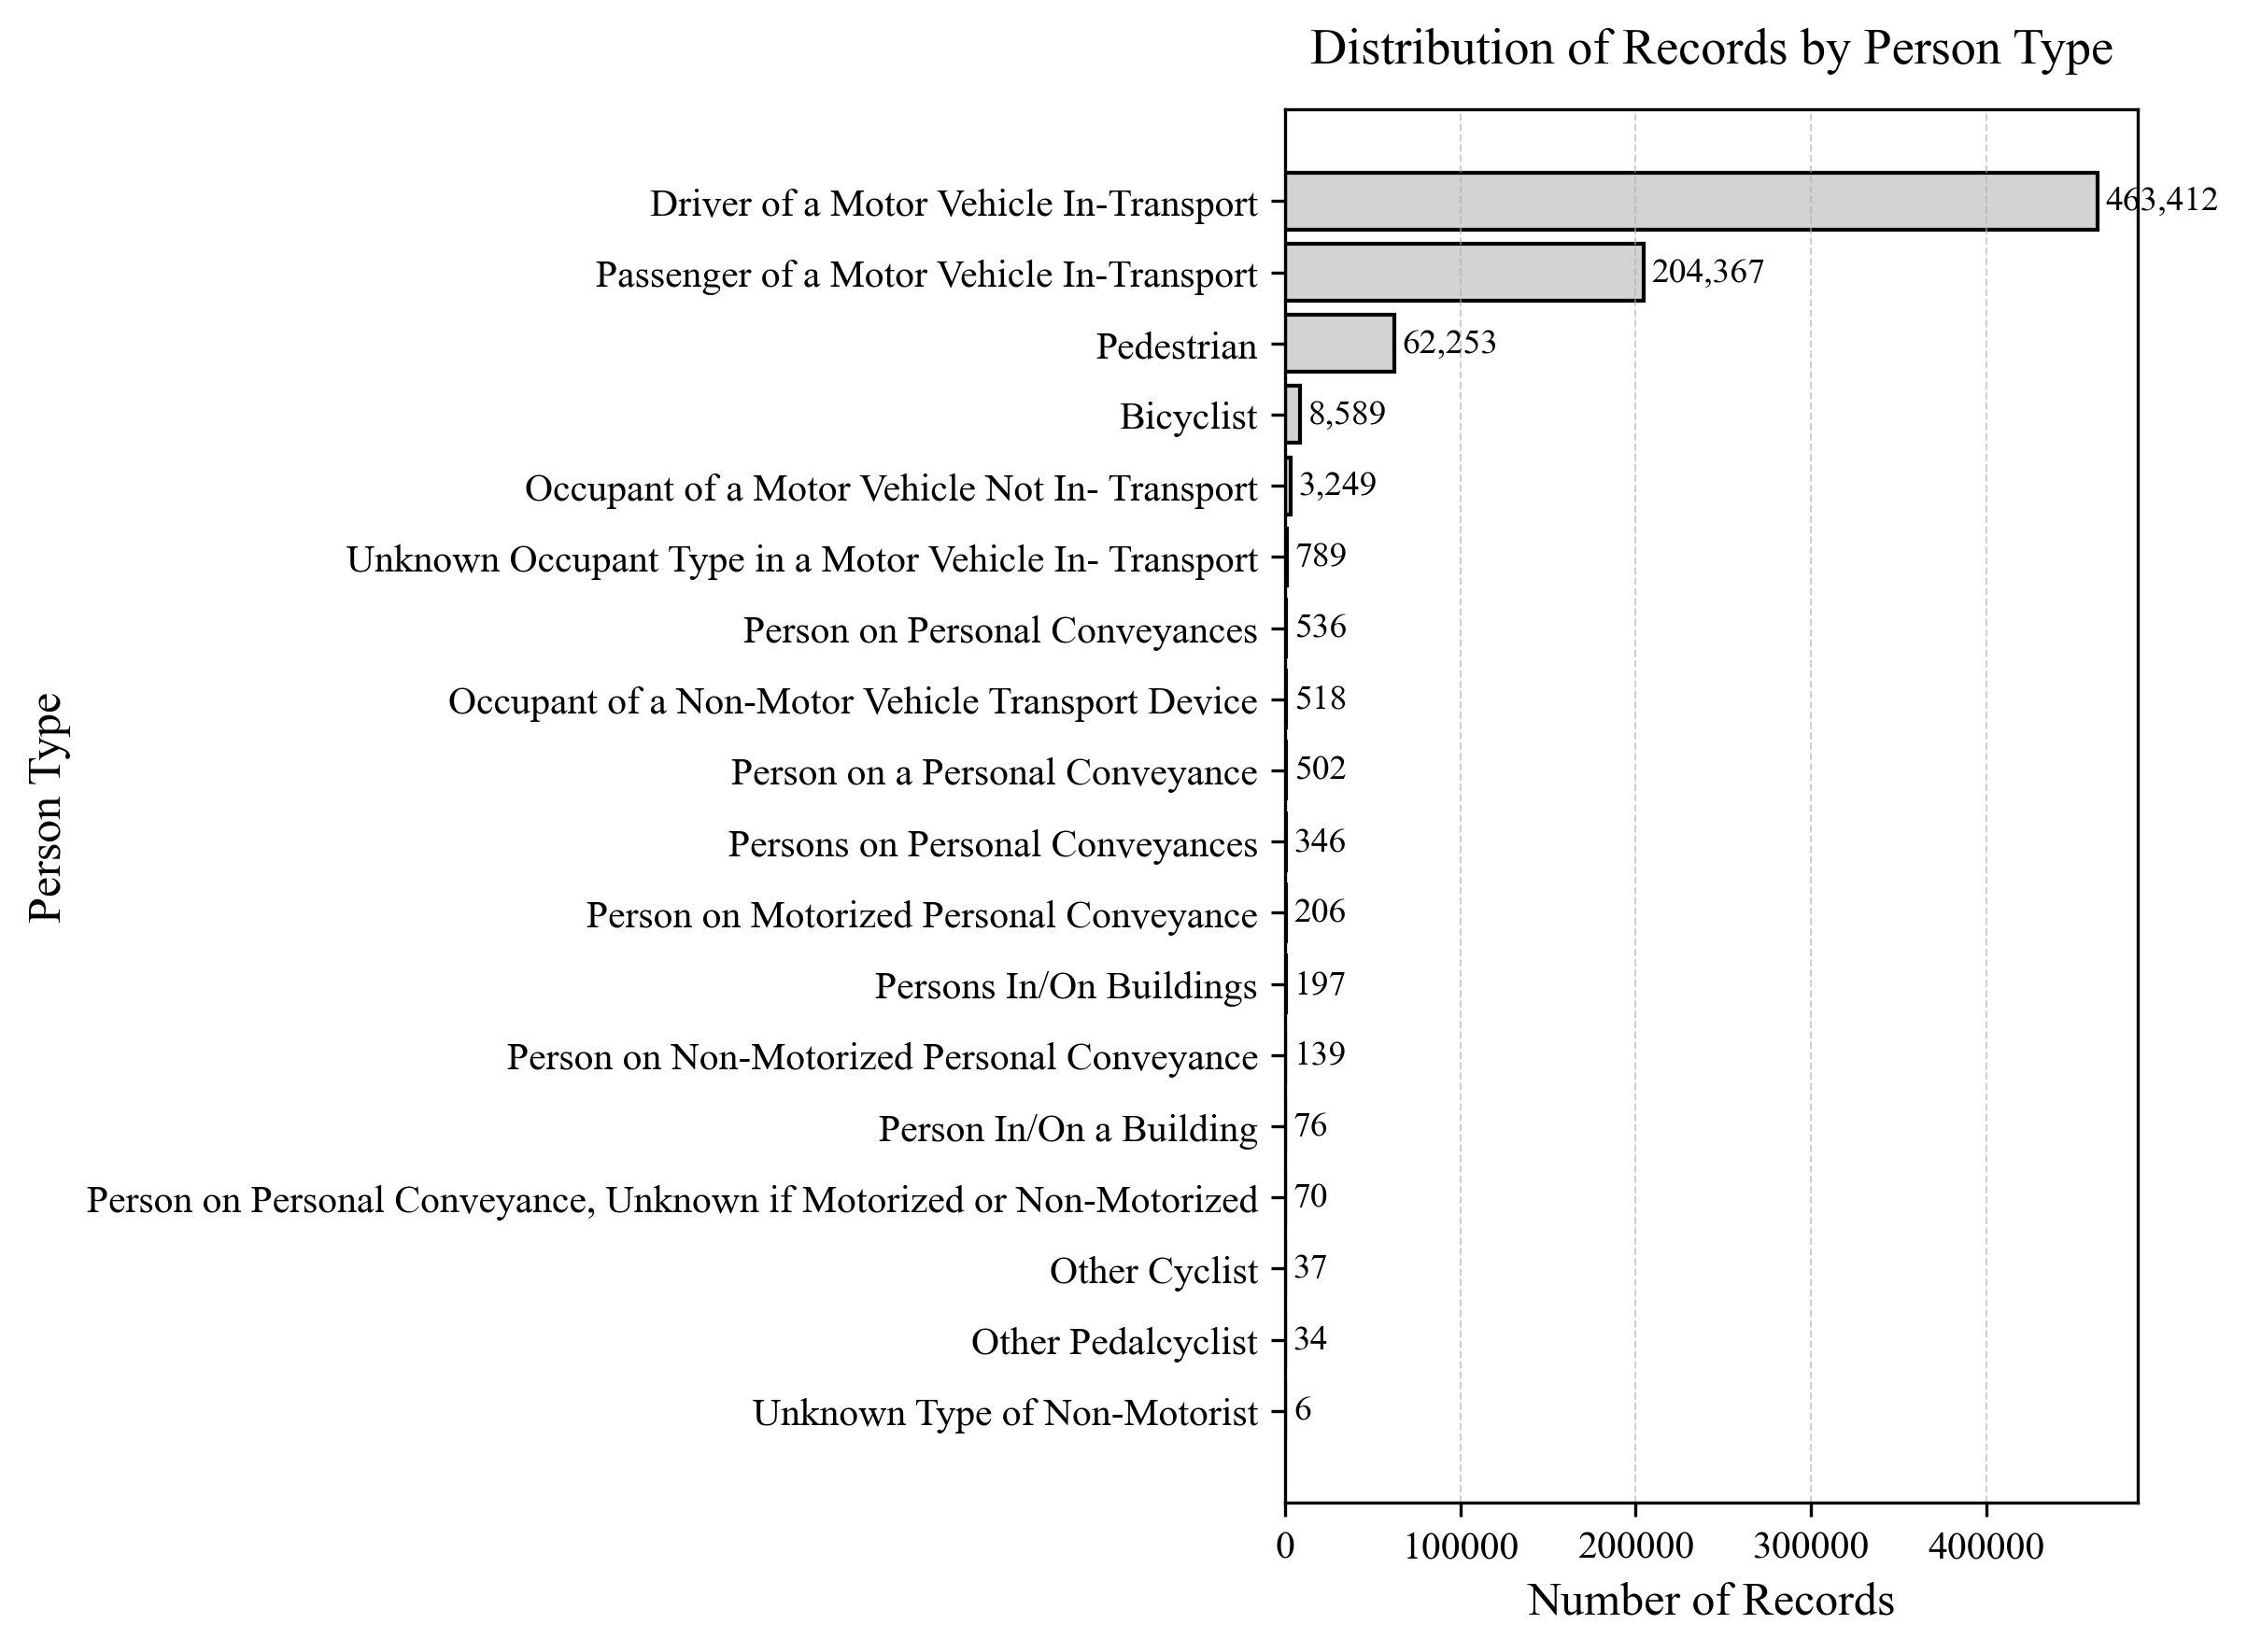

In [16]:
# ============================================================
# Horizontal Bar Chart: Data Depth by PER_TYPNAME
# Input: df with column "PER_TYPNAME"
# Output: Clean, publication-ready horizontal bar figure
# ============================================================
# 1. Aggregate data by person type
# ------------------------------------------------------------
person_counts = (
    df["PER_TYPNAME"]
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={"index": "PER_TYPNAME", "PER_TYPNAME": "Count"})
)

# Sort ascending so largest appears at top when plotted horizontally
person_counts = person_counts.sort_values("Count", ascending=True)

# ------------------------------------------------------------
# 2. Set up figure and style
# ------------------------------------------------------------
plt.rcParams["font.family"] = "Times New Roman"
plt.figure(figsize=(8, 6), dpi=300)

bars = plt.barh(
    person_counts["PER_TYPNAME"],
    person_counts["Count"],
    color="lightgray",
    edgecolor="black",
)

# ------------------------------------------------------------
# 3. Add count labels to each bar
# ------------------------------------------------------------
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + person_counts["Count"].max() * 0.01,  # small offset to the right
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center",
        fontsize=9,
    )

# ------------------------------------------------------------
# 4. Format axes and title
# ------------------------------------------------------------
plt.xlabel("Number of Records", fontsize=12)
plt.ylabel("Person Type", fontsize=12)
plt.title("Distribution of Records by Person Type", fontsize=13, pad=12)

plt.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.6)
plt.tight_layout()

# ------------------------------------------------------------
# 5. Export for journal use
# ------------------------------------------------------------
plt.savefig("fig_person_type_distribution.svg", bbox_inches="tight")           # vector format
plt.savefig("fig_person_type_distribution.png", bbox_inches="tight", dpi=300)  # high-DPI raster
plt.show()


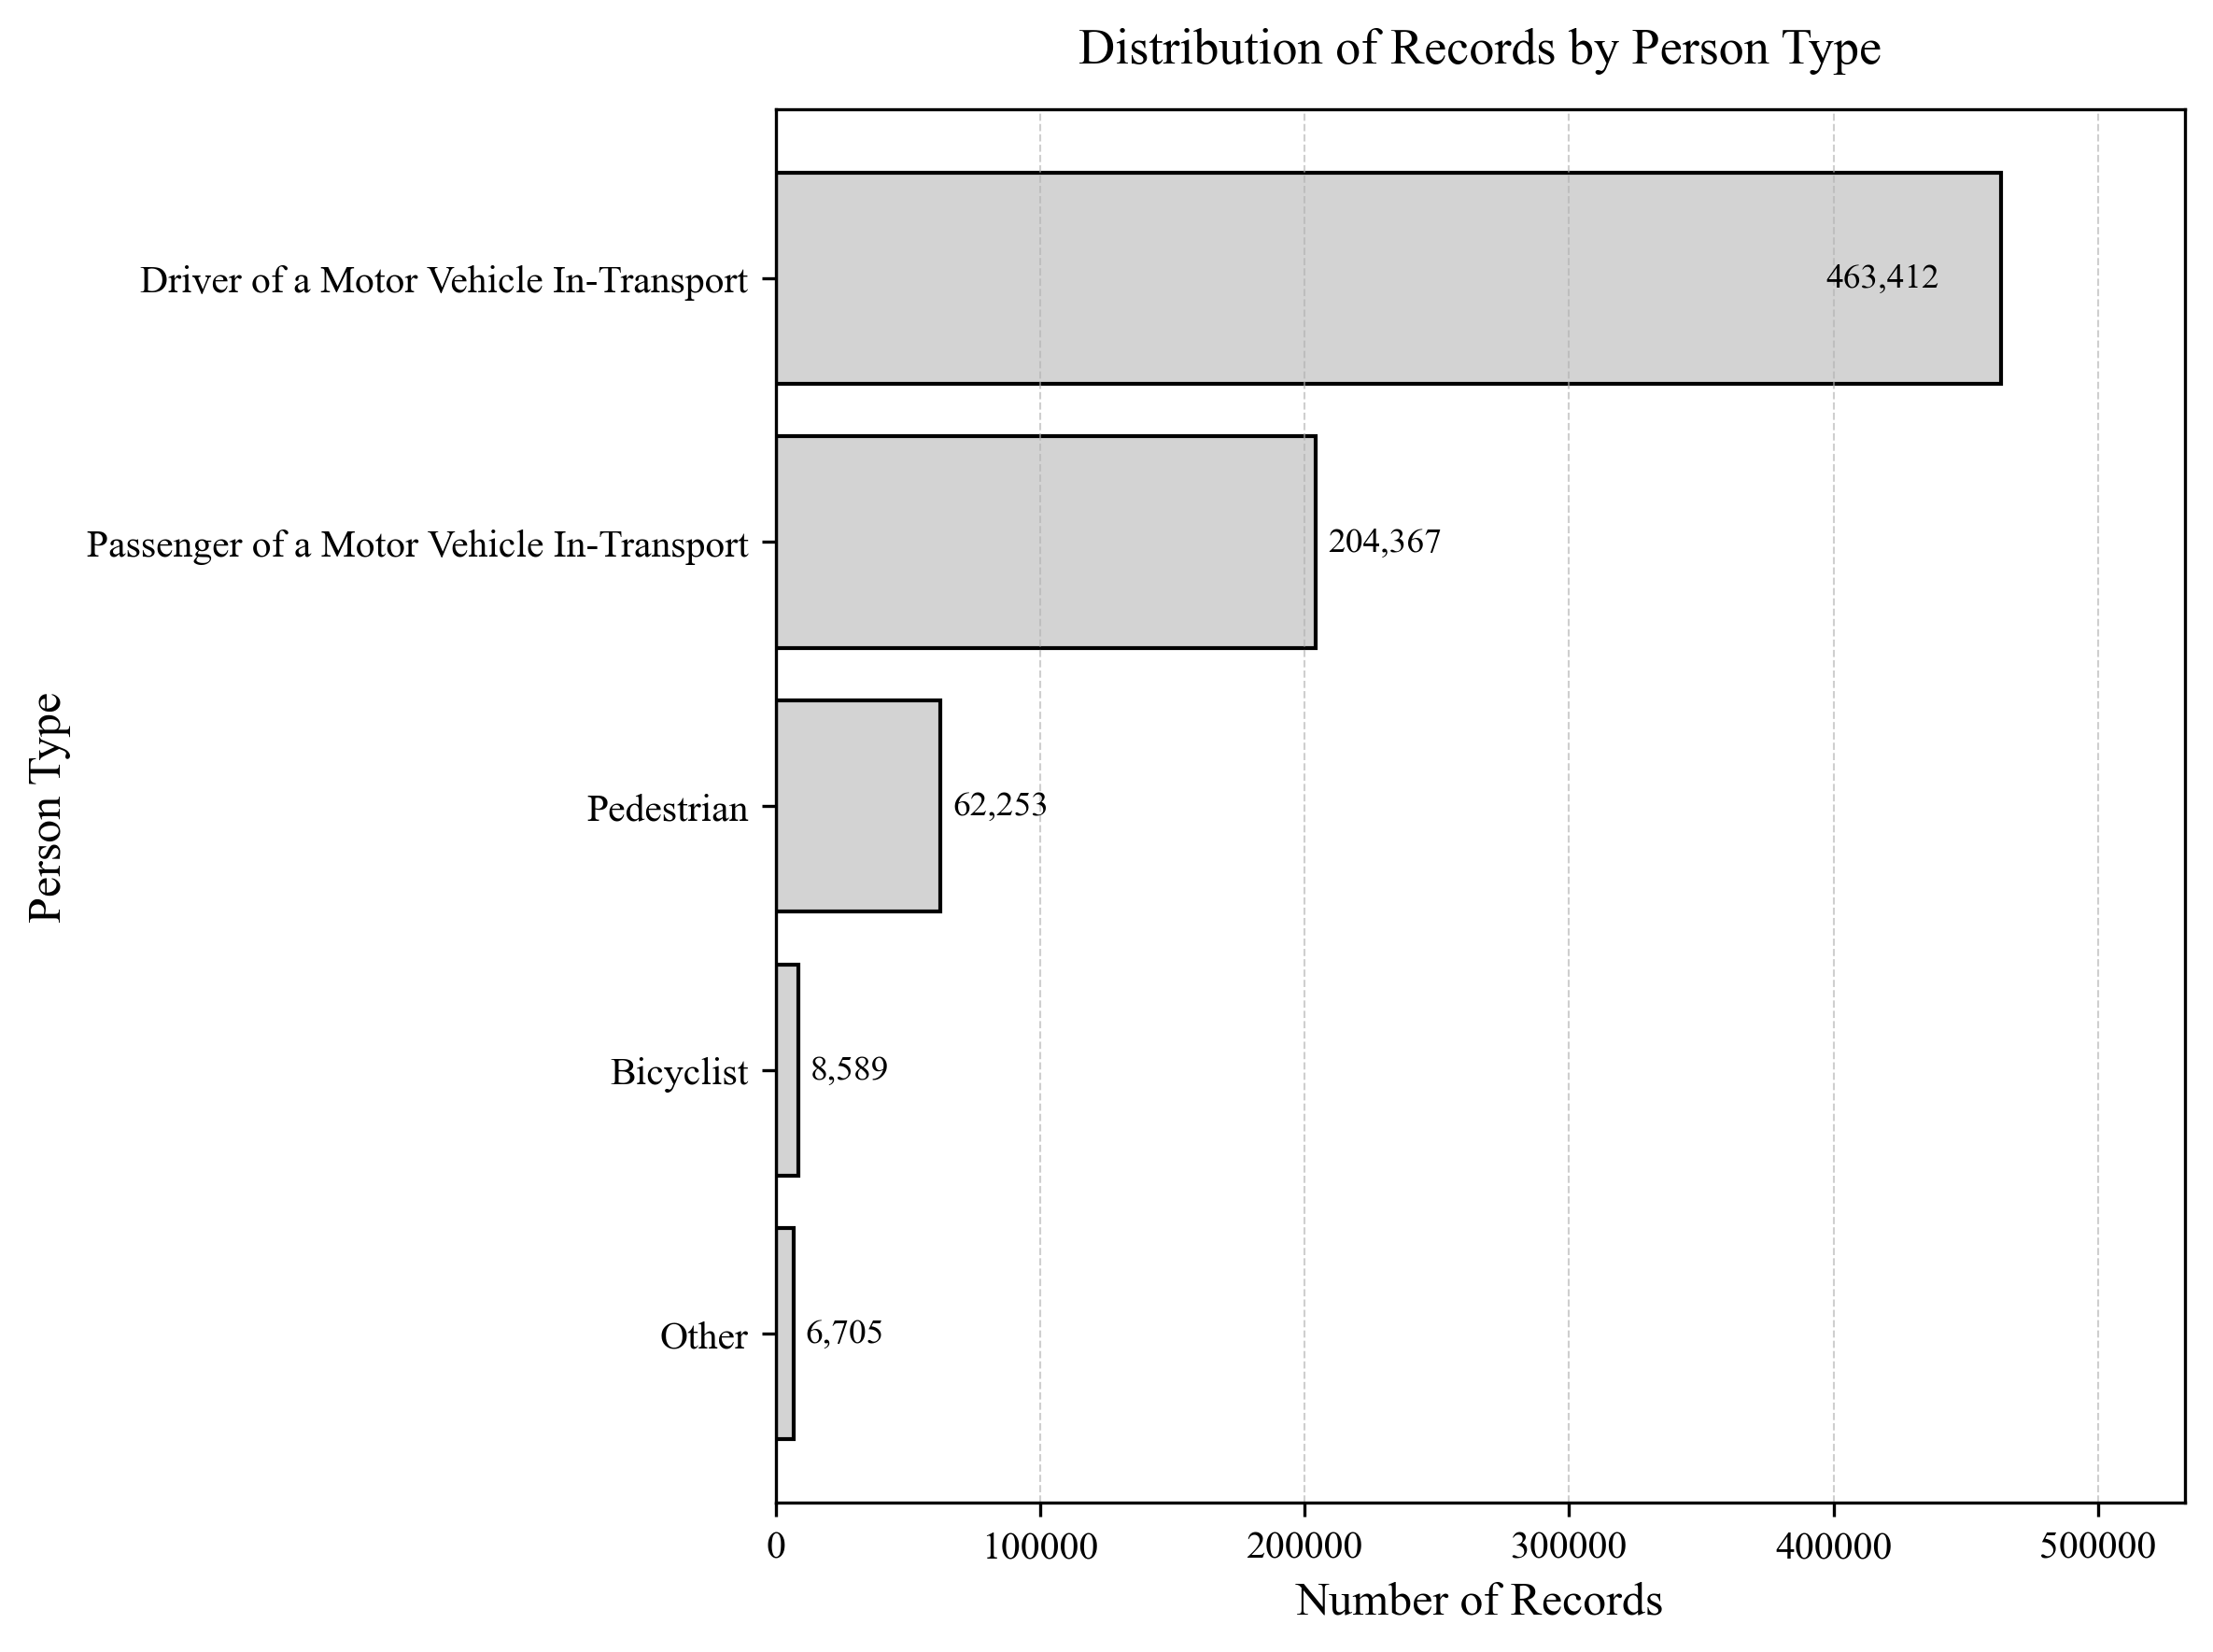

In [17]:
# ============================================================
# Fix label clipping in horizontal bar chart (auto-margin + adaptive labels)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Aggregate data (as before)
# ------------------------------------------------------------
person_counts = (
    df["PER_TYPNAME"]
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={"index": "PER_TYPNAME", "PER_TYPNAME": "Count"})
)

# Group smaller types below 'Bicyclist' into 'Other'
person_counts = person_counts.sort_values("Count", ascending=False).reset_index(drop=True)
cutoff_label = "Bicyclist"
cutoff_idx = (
    person_counts.index[person_counts["PER_TYPNAME"] == cutoff_label][0]
    if cutoff_label in person_counts["PER_TYPNAME"].values
    else 3
)
top_cats = person_counts.iloc[:cutoff_idx + 1].copy()
other_sum = person_counts.iloc[cutoff_idx + 1:]["Count"].sum()
person_counts_grouped = pd.concat(
    [top_cats, pd.DataFrame({"PER_TYPNAME": ["Other"], "Count": [other_sum]})],
    ignore_index=True,
).sort_values("Count", ascending=True)

# ------------------------------------------------------------
# 2. Plot with adaptive labels and extra right margin
# ------------------------------------------------------------
plt.rcParams["font.family"] = "Times New Roman"
plt.figure(figsize=(8, 6), dpi=300)

bars = plt.barh(
    person_counts_grouped["PER_TYPNAME"],
    person_counts_grouped["Count"],
    color="lightgray",
    edgecolor="black",
)

# Compute threshold to decide inside vs outside label placement
max_val = person_counts_grouped["Count"].max()
threshold = max_val * 0.85  # if bar width > 85% of max, label goes inside

for bar in bars:
    width = bar.get_width()
    if width > threshold:
        # Put label *inside* the bar for long bars
        plt.text(
            width - (max_val * 0.05),
            bar.get_y() + bar.get_height() / 2,
            f"{int(width):,}",
            va="center",
            ha="right",
            fontsize=9,
            color="black",
        )
    else:
        # Put label *outside* the bar for shorter ones
        plt.text(
            width + max_val * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{int(width):,}",
            va="center",
            ha="left",
            fontsize=9,
        )

# ------------------------------------------------------------
# 3. Aesthetics and layout
# ------------------------------------------------------------
plt.xlabel("Number of Records", fontsize=12)
plt.ylabel("Person Type", fontsize=12)
plt.title("Distribution of Records by Person Type", fontsize=13, pad=12)
plt.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.6)

# Add extra space on right for labels that might extend
plt.margins(x=0.15)

plt.tight_layout()
plt.savefig("fig_person_type_grouped_other_fixed.svg", bbox_inches="tight")
plt.savefig("fig_person_type_grouped_other_fixed.png", bbox_inches="tight", dpi=300)
plt.show()


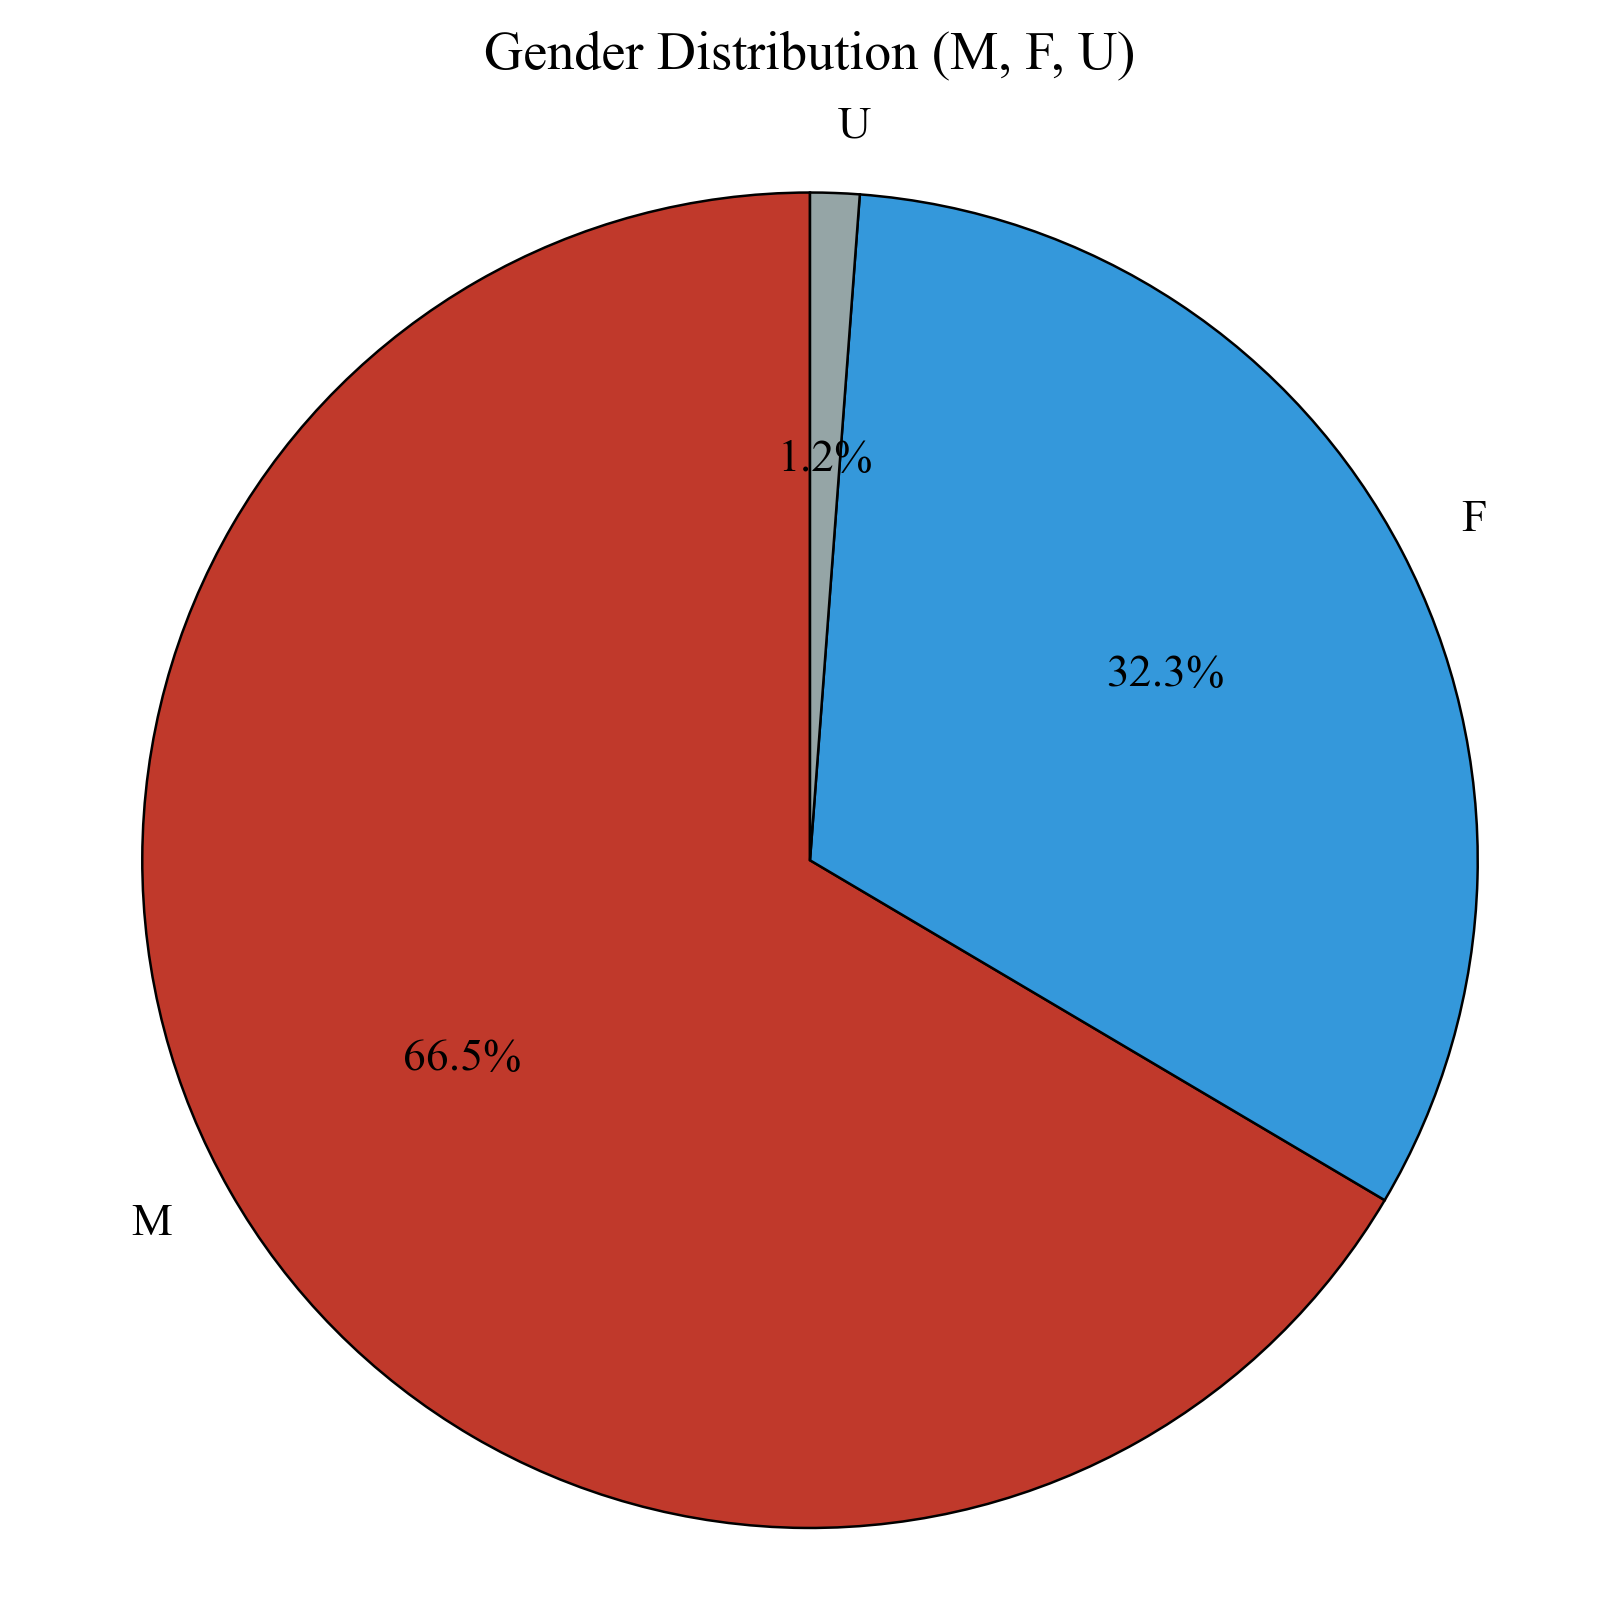

In [18]:
# ============================================================
# Compact Gender Distribution Pie Chart (M, F, U)
# - Groups all unknown/missing as U
# - Clean journal-quality layout
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Standardize categories (M, F, U)
# ------------------------------------------------------------
sex = (
    df["SEXNAME"]
    .astype(str)
    .str.strip()
    .str.upper()  # normalize to uppercase
)

# Map variants
sex = sex.replace({
    "MALE": "M", "M": "M",
    "FEMALE": "F", "F": "F",
    "UNKNOWN": "U", "UNK": "U", "UNKN": "U", "NA": "U",
    "NONE": "U", "": "U", "NAN": "U"
})

# Fallback: everything else also set to "U"
sex = sex.where(sex.isin(["M", "F", "U"]), other="U")

# ------------------------------------------------------------
# 2. Aggregate counts
# ------------------------------------------------------------
counts = sex.value_counts().reindex(["M", "F", "U"], fill_value=0)
labels = counts.index
sizes = counts.values
percentages = sizes / sizes.sum() * 100

# ------------------------------------------------------------
# 3. Plot configuration (journal style)
# ------------------------------------------------------------
plt.rcParams["font.family"] = "Times New Roman"
fig, ax = plt.subplots(figsize=(5.5, 5.5), dpi=300)

# Elegant neutral color palette
colors = ["#c0392b", "#3498db", "#95a5a6"]  # Red=Male, Blue=Female, Gray=Unknown

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 11},
    wedgeprops={"edgecolor": "black", "linewidth": 0.6},
)

# Center title
ax.set_title("Gender Distribution (M, F, U)", fontsize=13, pad=15)
ax.axis("equal")  # Equal aspect ratio for a perfect circle

# ------------------------------------------------------------
# 4. Save outputs
# ------------------------------------------------------------
plt.tight_layout()
plt.savefig("fig_gender_distribution_MFU.svg", bbox_inches="tight")   # vector
plt.savefig("fig_gender_distribution_MFU.png", bbox_inches="tight", dpi=300)  # 300-DPI PNG
plt.show()


Accident Dataset Summary (By STATE CASE + YEAR)
Total Records:          745,326
Unique Accident Cases:  321,847
Duplicate Records:      423,479
Duplicate Ratio:        56.82%

Average records per accident case: 2.32
Most records in a single case: 128


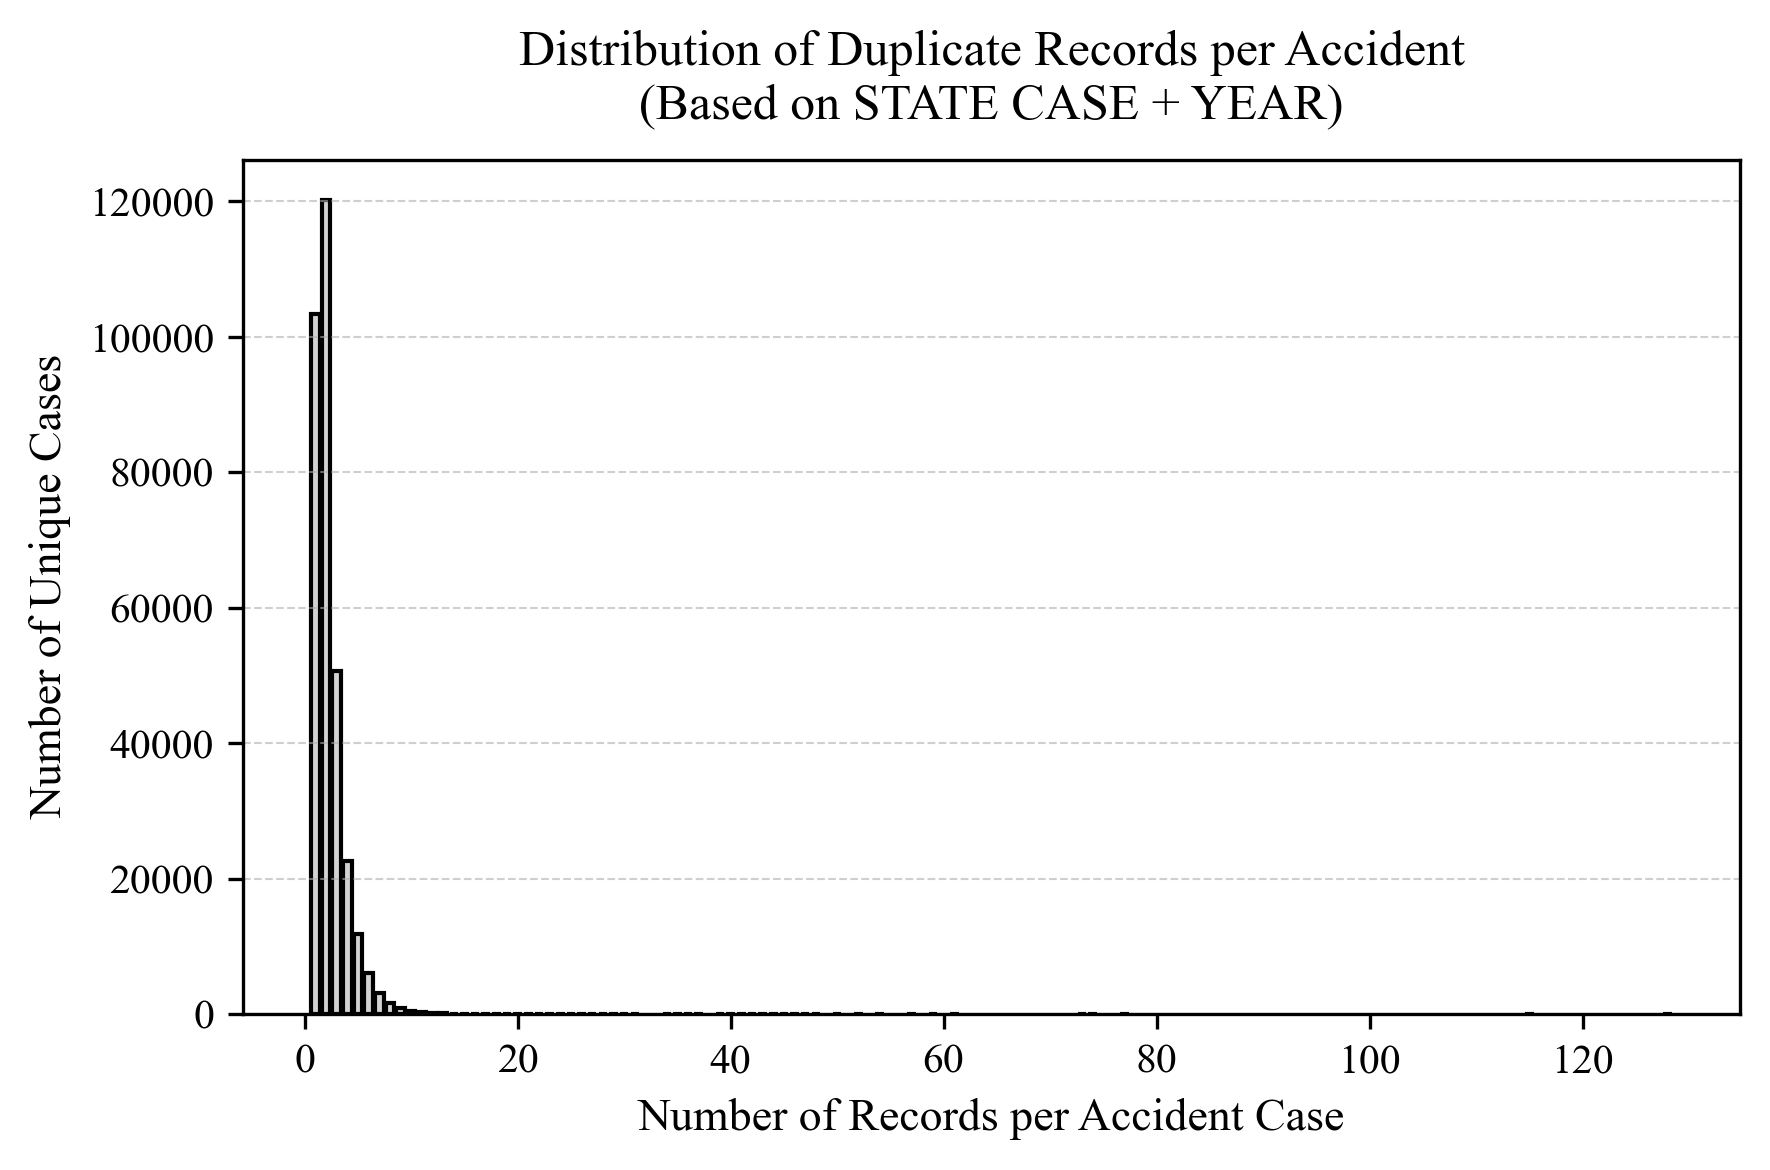

In [19]:
# ============================================================
# Unique Accident Summary (STATE CASE + YEAR)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Total records
# ------------------------------------------------------------
total_records = len(df)

# ------------------------------------------------------------
# 2. Unique accidents by combination of STATE CASE + YEAR
# ------------------------------------------------------------
unique_accidents = df.drop_duplicates(subset=["ST_CASE", "YEAR"])
unique_count = len(unique_accidents)

# ------------------------------------------------------------
# 3. Compute duplication metrics
# ------------------------------------------------------------
duplicate_count = total_records - unique_count
duplicate_ratio = (duplicate_count / total_records) * 100

print("===============================================")
print("Accident Dataset Summary (By STATE CASE + YEAR)")
print("===============================================")
print(f"Total Records:          {total_records:,}")
print(f"Unique Accident Cases:  {unique_count:,}")
print(f"Duplicate Records:      {duplicate_count:,}")
print(f"Duplicate Ratio:        {duplicate_ratio:.2f}%")
print("===============================================")

# ------------------------------------------------------------
# 4. Optional: check record frequency per accident
# ------------------------------------------------------------
case_freq = (
    df.groupby(["ST_CASE", "YEAR"])
      .size()
      .reset_index(name="Record_Count")
)

print("\nAverage records per accident case:", round(case_freq["Record_Count"].mean(), 2))
print("Most records in a single case:", int(case_freq["Record_Count"].max()))

# ------------------------------------------------------------
# 5. Optional: visualize distribution of repetition depth
# ------------------------------------------------------------
rep_dist = (
    case_freq["Record_Count"]
    .value_counts()
    .sort_index()
    .rename_axis("Records per Case")
    .reset_index(name="Number of Cases")
)

plt.rcParams["font.family"] = "Times New Roman"
plt.figure(figsize=(6, 4), dpi=300)
plt.bar(rep_dist["Records per Case"], rep_dist["Number of Cases"],
        color="lightgray", edgecolor="black")

plt.xlabel("Number of Records per Accident Case", fontsize=11)
plt.ylabel("Number of Unique Cases", fontsize=11)
plt.title("Distribution of Duplicate Records per Accident\n(Based on STATE CASE + YEAR)", fontsize=12, pad=10)
plt.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.savefig("fig_accident_duplicate_distribution_stateyear.png", dpi=300, bbox_inches="tight")
plt.show()


In [20]:
# ============================================================
# Simple audit for CATEGORICAL variables only
# ------------------------------------------------------------
# Usage:
#   cat_overview, cat_values = audit_categoricals(df, topn=30, rare_thresh=0.01)
#   cat_overview.head()
#   cat_values["PER_TYPNAME"]   # value-counts table for that column
# ============================================================

import pandas as pd
from pandas.api.types import is_categorical_dtype

def audit_categoricals(
    df: pd.DataFrame,
    topn: int = 30,
    rare_thresh: float = None,   # e.g., 0.01 for 1% => combine into "Other" in the counts table
    include_numeric_as_categorical_threshold: int = 0  # e.g., 10 => treat numeric columns with <=10 uniques as categorical
):
    # 1) pick categorical columns (object or categorical or small-cardinality numeric if chosen)
    cat_cols = []
    for c in df.columns:
        s = df[c]
        if s.dtype == "object" or is_categorical_dtype(s):
            cat_cols.append(c)
        elif include_numeric_as_categorical_threshold and pd.api.types.is_numeric_dtype(s):
            if s.nunique(dropna=True) <= include_numeric_as_categorical_threshold:
                cat_cols.append(c)

    overview_rows = []
    values_dict = {}

    n_rows = len(df)
    for col in cat_cols:
        s = df[col]
        miss = s.isna().sum()
        nunique = s.nunique(dropna=True)

        # Overview entry
        overview_rows.append({
            "column": col,
            "rows": n_rows,
            "non_null": n_rows - miss,
            "missing": miss,
            "missing_%": round(miss / n_rows * 100, 2),
            "unique_non_null": int(nunique),
        })

        # Value-counts table (optionally with rare collapsing)
        vc = s.value_counts(dropna=False).rename_axis(col).reset_index(name="count")
        vc["percent"] = (vc["count"] / n_rows * 100).round(2)

        if rare_thresh is not None:
            # Mark rare categories among NON-NaN entries only
            vc2 = s.fillna("__NA__").value_counts(normalize=True)
            rare_labels = set(vc2[vc2 < rare_thresh].index) - {"__NA__"}

            s_collapsed = s.fillna("__NA__").where(~s.fillna("__NA__").isin(rare_labels), other="Other")
            vc = s_collapsed.value_counts(dropna=False).rename_axis(col).reset_index(name="count")
            vc[col] = vc[col].replace({"__NA__": pd.NA})
            vc["percent"] = (vc["count"] / n_rows * 100).round(2)

        values_dict[col] = vc.head(topn)

    cat_overview = pd.DataFrame(overview_rows).sort_values(
        ["missing_%", "unique_non_null"], ascending=[False, True]
    ).reset_index(drop=True)

    return cat_overview, values_dict

# -----------------------------
# Example quick use
# -----------------------------
cat_overview, cat_values = audit_categoricals(df, topn=25, rare_thresh=0.01)
print(cat_overview.to_string(index=False))


                 column   rows  non_null  missing  missing_%  unique_non_null
           FIRE_EXPNAME 745326    745326        0        0.0                2
injury_severity_classes 745326    745326        0        0.0                2
            RUR_URBNAME 745326    745326        0        0.0                5
                SEXNAME 745326    745326        0        0.0                5
           DRINKINGNAME 745326    745326        0        0.0                5
           ROLLOVERNAME 745326    745326        0        0.0                6
            INJ_SEVNAME 745326    745326        0        0.0                7
           EJECTIONNAME 745326    745326        0        0.0                8
           DRUG_DETNAME 745326    745326        0        0.0                8
           LGT_CONDNAME 745326    745326        0        0.0               10
              MONTHNAME 745326    745326        0        0.0               12
           FUNC_SYSNAME 745326    745326        0        0.0    

In [21]:
# ============================================================
# Print unique values (and their counts) for categorical columns
# ============================================================

import pandas as pd

# List of categorical columns you want to inspect
categorical_features = [
    "FIRE_EXPNAME",
    "injury_severity_classes",
    "RUR_URBNAME",
    "SEXNAME",
    "DRINKINGNAME",
    "ROLLOVERNAME",
    "INJ_SEVNAME",
    "EJECTIONNAME",
    "DRUG_DETNAME",
    "LGT_CONDNAME",
    "MONTHNAME",
    "FUNC_SYSNAME",
    "MAN_COLLNAME",
    "AIR_BAGNAME",
    "PER_TYPNAME",
    "ROUTENAME",
    "REST_USENAME",
    "SEAT_POSNAME",
    "RD_OWNERNAME",
    "STATENAME",
    "HARM_EVNAME",
    "WEATHER1NAME"
]

# ------------------------------------------------------------
# Loop through each categorical column and print its details
# ------------------------------------------------------------
for col in categorical_features:
    print("=" * 80)
    print(f"Column: {col}")
    print("-" * 80)
    
    # Count unique values (sorted by frequency)
    value_counts = df[col].value_counts(dropna=False)
    
    # Print the unique values and counts
    for val, cnt in value_counts.items():
        percent = (cnt / len(df)) * 100
        print(f"{val:40} | {cnt:8,d} | {percent:6.2f}%")
    
    # Print summary line
    print("-" * 80)
    print(f"Unique non-null values: {df[col].nunique(dropna=True)}")
    print(f"Missing values: {df[col].isna().sum():,}")
    print("=" * 80 + "\n")


Column: FIRE_EXPNAME
--------------------------------------------------------------------------------
No or Not Reported                       |  722,285 |  96.91%
Yes                                      |   23,041 |   3.09%
--------------------------------------------------------------------------------
Unique non-null values: 2
Missing values: 0

Column: injury_severity_classes
--------------------------------------------------------------------------------
Non-Fatal                                |  395,702 |  53.09%
Fatal Injury                             |  349,624 |  46.91%
--------------------------------------------------------------------------------
Unique non-null values: 2
Missing values: 0

Column: RUR_URBNAME
--------------------------------------------------------------------------------
Urban                                    |  439,744 |  59.00%
Rural                                    |  302,855 |  40.63%
Trafficway Not in State Inventory        |    1,717 |   0.23

In [22]:
df_model=df

In [23]:
from sklearn.model_selection import GroupShuffleSplit

groups = df_model["ST_CASE"]  # crash identifier
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(df_model, groups=groups))

df_train, df_test = df_model.iloc[train_idx], df_model.iloc[test_idx]

In [24]:
# After splitting
y_train = df_train["injury_severity_class"]
y_test  = df_test["injury_severity_class"]

# Drop target + ID columns
drop_cols = ['injury_severity_classes',"injury_severity_class","ST_CASE","INJ_SEVNAME"]
X_train = df_train.drop(columns=drop_cols)
X_test  = df_test.drop(columns=drop_cols)


In [25]:
X_train

,YEAR,STATENAME,MONTHNAME,HOUR,RUR_URBNAME,FUNC_SYSNAME,HARM_EVNAME,MAN_COLLNAME,ROLLOVERNAME,FIRE_EXPNAME,...,SEAT_POSNAME,REST_USENAME,AIR_BAGNAME,EJECTIONNAME,DRINKINGNAME,DRUG_DETNAME,ROUTENAME,RD_OWNERNAME,LGT_CONDNAME,WEATHER1NAME
0,2015,Alabama,January,2,Rural,Principal Arterial - Other,Embankment,Not a Collision with Motor Vehicle In-Transport,No Rollover,No or Not Reported,...,"Front Seat, Left Side",None Used,Deployed- Front,Not Ejected,Unknown (Police Reported),Not Reported,State Highway,State Highway Agency,Dark - Not Lighted,Clear
2,2015,Alabama,January,1,Rural,Principal Arterial - Other,Tree (Standing Only),Not a Collision with Motor Vehicle In-Transport,"Rollover, Tripped by Object/Vehicle",Yes,...,"Front Seat, Left Side",None Used,Deployed- Front,Not Ejected,Yes (Alcohol Involved),Not Reported,U.S. Highway,State Highway Agency,Dark - Not Lighted,Clear
4,2015,Alabama,January,0,Rural,Minor Arterial,Mail Box,Not a Collision with Motor Vehicle In-Transport,No Rollover,No or Not Reported,...,"Front Seat, Left Side",None Used,Not Deployed,Not Ejected,Yes (Alcohol Involved),Not Reported,State Highway,State Highway Agency,Dark - Not Lighted,Cloudy
7,2015,Alabama,January,9,Rural,Major Collector,Rollover/Overturn,Not a Collision with Motor Vehicle In-Transport,"Rollover, Tripped by Object/Vehicle",No or Not Reported,...,"Front Seat, Left Side",None Used,Not Deployed,Totally Ejected,No (Alcohol Not Involved),Not Reported,County Road,County Highway Agency,Daylight,Clear
8,2015,Alabama,January,9,Rural,Major Collector,Rollover/Overturn,Not a Collision with Motor Vehicle In-Transport,"Rollover, Tripped by Object/Vehicle",No or Not Reported,...,"Front Seat, Right Side",Shoulder and Lap Belt Used,Not Deployed,Not Ejected,Not Reported,Not Reported,County Road,County Highway Agency,Daylight,Clear
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
793179,2023,Wyoming,December,8,Rural,Other Principal Arterial,Motor Vehicle In-Transport,Angle,No Rollover,No or Not Reported,...,"Front Seat, Right Side",Shoulder and Lap Belt Used,Deployed- Front,Not Ejected,Not Reported,Not Reported,U.S. Highway,State Highway Agency,Daylight,Not Reported
793180,2023,Wyoming,December,8,Rural,Other Principal Arterial,Motor Vehicle In-Transport,Angle,No Rollover,No or Not Reported,...,"Second Seat, Right Side",Shoulder and Lap Belt Used,Not Deployed,Not Ejected,Not Reported,Not Reported,U.S. Highway,State Highway Agency,Daylight,Not Reported
793181,2023,Wyoming,December,8,Rural,Other Principal Arterial,Motor Vehicle In-Transport,Angle,No Rollover,No or Not Reported,...,"Second Seat, Middle",Shoulder and Lap Belt Used,Not Deployed,Not Ejected,Not Reported,Not Reported,U.S. Highway,State Highway Agency,Daylight,Not Reported
793182,2023,Wyoming,December,8,Rural,Other Principal Arterial,Motor Vehicle In-Transport,Angle,No Rollover,No or Not Reported,...,"Second Seat, Left Side",Shoulder and Lap Belt Used,"Deployed- Side (door, seatback)",Totally Ejected,Not Reported,Not Reported,U.S. Highway,State Highway Agency,Daylight,Not Reported


In [26]:
from sklearn.preprocessing import OrdinalEncoder
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical cols:", cat_cols)
print("Numeric cols:", num_cols[:10], "...")  # preview

enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

X_train_enc[cat_cols] = enc.fit_transform(X_train[cat_cols])
X_test_enc[cat_cols] = enc.transform(X_test[cat_cols])

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_enc, y_train)

y_pred = rf.predict(X_test_enc)
print(classification_report(y_test, y_pred, target_names=["Non-Fatal","Fatal Injury"]))


Categorical cols: ['STATENAME', 'MONTHNAME', 'RUR_URBNAME', 'FUNC_SYSNAME', 'HARM_EVNAME', 'MAN_COLLNAME', 'ROLLOVERNAME', 'FIRE_EXPNAME', 'SEXNAME', 'PER_TYPNAME', 'SEAT_POSNAME', 'REST_USENAME', 'AIR_BAGNAME', 'EJECTIONNAME', 'DRINKINGNAME', 'DRUG_DETNAME', 'ROUTENAME', 'RD_OWNERNAME', 'LGT_CONDNAME', 'WEATHER1NAME']
Numeric cols: ['YEAR', 'HOUR', 'AGE'] ...
              precision    recall  f1-score   support

   Non-Fatal       0.84      0.86      0.85     78948
Fatal Injury       0.84      0.81      0.83     69958

    accuracy                           0.84    148906
   macro avg       0.84      0.84      0.84    148906
weighted avg       0.84      0.84      0.84    148906



In [27]:
# ==========================================
# Random Forest on encoded data (comparable)
# Reuses: X_train_enc, X_test_enc, y_train, y_test
# ==========================================
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, precision_recall_curve,
    classification_report, confusion_matrix
)

# Clean labels
ytr = np.asarray(y_train).astype(int).ravel()
yte = np.asarray(y_test).astype(int).ravel()

# RF with imbalance handling (class_weight)
rf = RandomForestClassifier(
    n_estimators=400,          # bump to 600–1000 for final runs
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train_enc, ytr)

# ---- Probabilities and metrics ----
proba = rf.predict_proba(X_test_enc)[:, 1]

# Global metrics
roc = roc_auc_score(yte, proba)
brier = brier_score_loss(yte, proba)

# 1) Default 0.5 threshold
yhat_05 = (proba >= 0.5).astype(int)

print("\n=== Random Forest @ 0.5 threshold ===")
print("ROC-AUC:", round(roc, 4), "| Brier:", round(brier, 4))
print(classification_report(yte, yhat_05, target_names=["Non-Fatal","Fatal Injury"], digits=3))
print("Confusion matrix:\n", confusion_matrix(yte, yhat_05))

# 2) Best F1 threshold for the Fatal class (1)
prec, rec, thr = precision_recall_curve(yte, proba)
f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_i = int(np.nanargmax(f1))
best_thr = float(thr[best_i])

yhat_best = (proba >= best_thr).astype(int)

print(f"\n=== Random Forest @ best F1 (thr={best_thr:.3f}) ===")
print("ROC-AUC:", round(roc, 4), "| Brier:", round(brier, 4))
print(classification_report(yte, yhat_best, target_names=["Non-Fatal","Fatal Injury"], digits=3))
print("Confusion matrix:\n", confusion_matrix(yte, yhat_best))



=== Random Forest @ 0.5 threshold ===
ROC-AUC: 0.9207 | Brier: 0.1132
              precision    recall  f1-score   support

   Non-Fatal      0.843     0.858     0.850     78948
Fatal Injury      0.836     0.819     0.828     69958

    accuracy                          0.840    148906
   macro avg      0.839     0.838     0.839    148906
weighted avg      0.840     0.840     0.840    148906

Confusion matrix:
 [[67725 11223]
 [12655 57303]]

=== Random Forest @ best F1 (thr=0.439) ===
ROC-AUC: 0.9207 | Brier: 0.1132
              precision    recall  f1-score   support

   Non-Fatal      0.864     0.820     0.842     78948
Fatal Injury      0.808     0.854     0.831     69958

    accuracy                          0.836    148906
   macro avg      0.836     0.837     0.836    148906
weighted avg      0.838     0.836     0.836    148906

Confusion matrix:
 [[64759 14189]
 [10198 59760]]


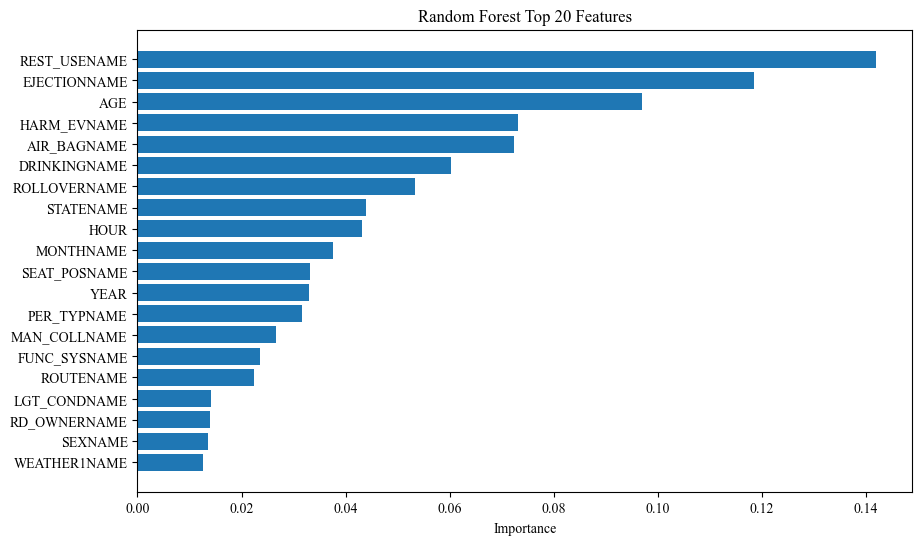

In [28]:
import matplotlib.pyplot as plt

# Get importances from the trained Random Forest (rf)
importances = rf.feature_importances_

# Put into DataFrame
feat_importance_df = pd.DataFrame({
    "feature": X_train_enc.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

feat_importance_df.head(20)  # top 20
top_n = 20
plt.figure(figsize=(10,6))
plt.barh(
    feat_importance_df["feature"].head(top_n)[::-1],
    feat_importance_df["importance"].head(top_n)[::-1]
)
plt.xlabel("Importance")
plt.title(f"Random Forest Top {top_n} Features")
plt.show()

In [29]:
from xgboost import XGBClassifier
import numpy as np
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, precision_recall_curve, classification_report, confusion_matrix, brier_score_loss

# Make sure labels are clean ints
ytr = np.asarray(y_train).astype(int).ravel()
yte = np.asarray(y_test).astype(int).ravel()

# Handle imbalance
neg, pos = (ytr == 0).sum(), (ytr == 1).sum()
scale_w = float(neg / max(pos, 1))

xgb = XGBClassifier(
    n_estimators=600, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    tree_method="hist", eval_metric="logloss",
    scale_pos_weight=scale_w, random_state=42, n_jobs=-1
)

# Fit then calibrate (prefit = fast)
xgb.fit(X_train_enc, ytr)
try:
    cal = CalibratedClassifierCV(estimator=xgb, method="isotonic", cv=3)
except TypeError:
    cal = CalibratedClassifierCV(base_estimator=xgb, method="isotonic", cv=3)
cal.fit(X_train_enc, ytr)

proba = cal.predict_proba(X_test_enc)[:, 1]
prec, rec, thr = precision_recall_curve(yte, proba)
f1 = 2*prec[:-1]*rec[:-1]/(prec[:-1]+rec[:-1]+1e-12)
best_thr = float(thr[int(np.nanargmax(f1))])
yhat = (proba >= best_thr).astype(int)

print("ROC-AUC:", roc_auc_score(yte, proba).round(4), "| Brier:", brier_score_loss(yte, proba).round(4))
print(f"Best F1 threshold: {best_thr:.3f}")
print(classification_report(yte, yhat, target_names=["Non-Fatal","Fatal Injury"], digits=3))
print("Confusion matrix:\n", confusion_matrix(yte, yhat))


ROC-AUC: 0.8875 | Brier: 0.16
Best F1 threshold: 0.563
              precision    recall  f1-score   support

   Non-Fatal      0.841     0.762     0.800     78948
Fatal Injury      0.758     0.838     0.796     69958

    accuracy                          0.798    148906
   macro avg      0.800     0.800     0.798    148906
weighted avg      0.802     0.798     0.798    148906

Confusion matrix:
 [[60183 18765]
 [11336 58622]]


In [30]:
# ==============================================
# Stacking + Prefit Calibration on ENCODED DATA
# Reuses: X_train_enc, X_test_enc, y_train, y_test
# ==============================================
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, brier_score_loss,
    classification_report, confusion_matrix
)

RANDOM_STATE = 42
STACK_CV = 3  # faster; bump to 5 for final runs

# --- Guardrails: ensure labels are clean ints and no NaNs ---
y_train_arr = np.asarray(y_train).astype(int).ravel()
y_test_arr  = np.asarray(y_test).astype(int).ravel()
assert not np.isnan(y_train_arr).any() and not np.isnan(y_test_arr).any(), "y contains NaN"

# --- Calibration split from the existing TRAIN set (prefit calibration) ---
X_tr, X_cal, y_tr, y_cal = train_test_split(
    X_train_enc, y_train_arr, test_size=0.2, stratify=y_train_arr, random_state=RANDOM_STATE
)

# --- Base learners on your encoded features ---
rf = RandomForestClassifier(
    n_estimators=400, max_depth=None, min_samples_leaf=2,
    class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE
)

gbm = GradientBoostingClassifier(random_state=RANDOM_STATE)

# Optional: include XGBoost if installed
INCLUDE_XGB = False
estimators = [("rf", rf), ("gbm", gbm)]
if INCLUDE_XGB:
    try:
        from xgboost import XGBClassifier
        neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
        xgb = XGBClassifier(
            n_estimators=400, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
            tree_method="hist", eval_metric="logloss",
            scale_pos_weight=float(neg / max(pos, 1)),
            random_state=RANDOM_STATE, n_jobs=-1
        )
        estimators.append(("xgb", xgb))
        print("[info] XGBoost included in the stack.")
    except Exception as e:
        print(f"[warn] XGBoost not available ({e}). Proceeding without it.")

# --- Stacking meta-learner ---
meta = LogisticRegression(max_iter=2000, class_weight="balanced")
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=meta,
    passthrough=True,
    cv=StratifiedKFold(n_splits=STACK_CV, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1
)

# --- Fit stack once on X_tr, then calibrate on X_cal (prefit = fast) ---
stack.fit(X_tr, y_tr)
try:
    cal = CalibratedClassifierCV(estimator=stack, method="isotonic", cv="prefit")
except TypeError:
    cal = CalibratedClassifierCV(base_estimator=stack, method="isotonic", cv="prefit")
cal.fit(X_cal, y_cal)

# --- Evaluate on your existing TEST set ---
proba = cal.predict_proba(X_test_enc)[:, 1]

# F1-optimal threshold for Fatal class (1)
prec, rec, thr = precision_recall_curve(y_test_arr, proba)
f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_i = int(np.nanargmax(f1))
best_thr = float(thr[best_i])

yhat = (proba >= best_thr).astype(int)

print("\n=== Super Learner (Stacking, encoded data) ===")
print(f"Best threshold (F1+): {best_thr:.3f}")
print("ROC-AUC:", roc_auc_score(y_test_arr, proba).round(4))
print("Brier score:", brier_score_loss(y_test_arr, proba).round(4))
print("\nClassification report @ best threshold:")
print(classification_report(y_test_arr, yhat, target_names=["Non-Fatal","Fatal Injury"], digits=3))
print("Confusion matrix:\n", confusion_matrix(y_test_arr, yhat))


/Users/aerfani/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression




=== Super Learner (Stacking, encoded data) ===
Best threshold (F1+): 0.423
ROC-AUC: 0.9189
Brier score: 0.1139

Classification report @ best threshold:
              precision    recall  f1-score   support

   Non-Fatal      0.865     0.814     0.839     78948
Fatal Injury      0.803     0.856     0.829     69958

    accuracy                          0.834    148906
   macro avg      0.834     0.835     0.834    148906
weighted avg      0.836     0.834     0.834    148906

Confusion matrix:
 [[64285 14663]
 [10057 59901]]


In [31]:
# =========================
# Simple XGBoost (no calib)
# =========================
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve,
    classification_report, confusion_matrix
)

# Clean labels
ytr = np.asarray(y_train).astype(int).ravel()
yte = np.asarray(y_test).astype(int).ravel()

# Class imbalance weight
neg, pos = (ytr == 0).sum(), (ytr == 1).sum()
scale_w = float(neg / max(pos, 1))

xgb_simple = XGBClassifier(
    n_estimators=600,          # you can lower to 400 for speed
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    tree_method="hist",
    eval_metric="logloss",
    scale_pos_weight=scale_w,
    random_state=42,
    n_jobs=-1,
)

# Train
xgb_simple.fit(X_train_enc, ytr)

# Predict probabilities
proba = xgb_simple.predict_proba(X_test_enc)[:, 1]

# Metrics @ default 0.5
yhat_05 = (proba >= 0.5).astype(int)
print("\n=== XGBoost (simple) @ 0.5 ===")
print("ROC-AUC:", roc_auc_score(yte, proba).round(4))
print(classification_report(yte, yhat_05, target_names=["Non-Fatal","Fatal Injury"], digits=3))
print("Confusion matrix:\n", confusion_matrix(yte, yhat_05))

# Metrics @ best F1 for Fatal class
p, r, t = precision_recall_curve(yte, proba)
f1 = 2 * p[:-1] * r[:-1] / (p[:-1] + r[:-1] + 1e-12)
best_i = int(np.nanargmax(f1))
best_thr = float(t[best_i])
yhat_best = (proba >= best_thr).astype(int)

print(f"\n=== XGBoost (simple) @ best F1 (thr={best_thr:.3f}) ===")
print(classification_report(yte, yhat_best, target_names=["Non-Fatal","Fatal Injury"], digits=3))
print("Confusion matrix:\n", confusion_matrix(yte, yhat_best))



=== XGBoost (simple) @ 0.5 ===
ROC-AUC: 0.9266
              precision    recall  f1-score   support

   Non-Fatal      0.851     0.858     0.855     78948
Fatal Injury      0.838     0.831     0.835     69958

    accuracy                          0.845    148906
   macro avg      0.845     0.844     0.845    148906
weighted avg      0.845     0.845     0.845    148906

Confusion matrix:
 [[67720 11228]
 [11814 58144]]

=== XGBoost (simple) @ best F1 (thr=0.453) ===
              precision    recall  f1-score   support

   Non-Fatal      0.866     0.833     0.849     78948
Fatal Injury      0.819     0.854     0.836     69958

    accuracy                          0.843    148906
   macro avg      0.842     0.843     0.843    148906
weighted avg      0.844     0.843     0.843    148906

Confusion matrix:
 [[65732 13216]
 [10196 59762]]


In [32]:
# ==============================================
# Stacking + Prefit Calibration on ENCODED DATA
# Strengthened base diversity: RF + GBM + ExtraTrees + SGD
# Reuses: X_train_enc, X_test_enc, y_train, y_test
# ==============================================
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, StackingClassifier
)
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, brier_score_loss,
    classification_report, confusion_matrix
)

RANDOM_STATE = 42
STACK_CV = 3          # keep small for speed
INCLUDE_XGB = False   # set True if you want to add XGBoost as well

# --- Guardrails: ensure labels are clean ints and no NaNs ---
y_train_arr = np.asarray(y_train).astype(int).ravel()
y_test_arr  = np.asarray(y_test).astype(int).ravel()
assert not np.isnan(y_train_arr).any() and not np.isnan(y_test_arr).any(), "y contains NaN"

# --- Calibration split from the existing TRAIN set (prefit calibration) ---
X_tr, X_cal, y_tr, y_cal = train_test_split(
    X_train_enc, y_train_arr, test_size=0.2,
    stratify=y_train_arr, random_state=RANDOM_STATE
)

# --- Base learners (fast & diverse) ---
rf = RandomForestClassifier(
    n_estimators=400, max_depth=None, min_samples_leaf=2,
    class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE
)

gbm = GradientBoostingClassifier(random_state=RANDOM_STATE)

et = ExtraTreesClassifier(                 # very fast, different split randomness
    n_estimators=400, max_depth=None, min_samples_leaf=2,
    class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE
)

sgd = SGDClassifier(                        # fast linear model
    loss="log_loss", max_iter=2000, tol=1e-3,
    class_weight="balanced", random_state=RANDOM_STATE
)

estimators = [("rf", rf), ("gbm", gbm), ("et", et), ("sgd", sgd)]

# Optional: include XGBoost for stronger diversity
if INCLUDE_XGB:
    try:
        from xgboost import XGBClassifier
        neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
        xgb = XGBClassifier(
            n_estimators=400, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
            tree_method="hist", eval_metric="logloss",
            scale_pos_weight=float(neg / max(pos, 1)),
            random_state=RANDOM_STATE, n_jobs=-1
        )
        estimators.append(("xgb", xgb))
        print("[info] XGBoost included in the stack.")
    except Exception as e:
        print(f"[warn] XGBoost not available ({e}). Proceeding without it.")

# --- Stacking meta-learner (kept simple & fast) ---
meta = LogisticRegression(max_iter=2000, class_weight="balanced")

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=meta,
    passthrough=True,
    cv=StratifiedKFold(n_splits=STACK_CV, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1
)

# --- Fit stack once on X_tr, then calibrate on X_cal (prefit = fast) ---
stack.fit(X_tr, y_tr)
try:
    cal = CalibratedClassifierCV(estimator=stack, method="isotonic", cv="prefit")
except TypeError:
    cal = CalibratedClassifierCV(base_estimator=stack, method="isotonic", cv="prefit")
cal.fit(X_cal, y_cal)

# --- Evaluate on your existing TEST set ---
proba = cal.predict_proba(X_test_enc)[:, 1]

# F1-optimal threshold for Fatal class (1)
prec, rec, thr = precision_recall_curve(y_test_arr, proba)
f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_i = int(np.nanargmax(f1))
best_thr = float(thr[best_i])
yhat = (proba >= best_thr).astype(int)

print("\n=== Super Learner (Stacking, diversified base, encoded data) ===")
print(f"Best threshold (F1+): {best_thr:.3f}")
print("ROC-AUC:", roc_auc_score(y_test_arr, proba).round(4))
print("Brier score:", brier_score_loss(y_test_arr, proba).round(4))
print("\nClassification report @ best threshold:")
print(classification_report(y_test_arr, yhat, target_names=["Non-Fatal","Fatal Injury"], digits=3))
print("Confusion matrix:\n", confusion_matrix(y_test_arr, yhat))


/Users/aerfani/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression




=== Super Learner (Stacking, diversified base, encoded data) ===
Best threshold (F1+): 0.447
ROC-AUC: 0.9189
Brier score: 0.1137

Classification report @ best threshold:
              precision    recall  f1-score   support

   Non-Fatal      0.859     0.827     0.843     78948
Fatal Injury      0.813     0.847     0.830     69958

    accuracy                          0.836    148906
   macro avg      0.836     0.837     0.836    148906
weighted avg      0.837     0.836     0.837    148906

Confusion matrix:
 [[65271 13677]
 [10682 59276]]


In [33]:
# ==========================================================
# Quick-Wins Hybrid (FAST): group-aware CV + per-model calib
# Reuses: X_train_enc, X_test_enc, y_train, y_test
# ==========================================================
import numpy as np
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, precision_recall_curve,
    classification_report, confusion_matrix
)

RANDOM_STATE = 42
N_SPLITS = 3          # keep small for speed
ALPHA = 0.70          # utility weight on Recall (0..1). 0.7 => recall prioritized
N_BINS_ECE = 15       # bins for Expected Calibration Error

# -------------------------------
# Utilities
# -------------------------------
def clean_y(y):
    y = np.asarray(y).astype(int).ravel()
    if np.isnan(y).any():
        raise ValueError("y contains NaN")
    return y

def make_cv(y, groups=None, n_splits=3, seed=42):
    """Use StratifiedGroupKFold if groups provided; else StratifiedKFold."""
    if groups is not None:
        return StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

def expected_calibration_error(y_true, proba, n_bins=15):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    idx = np.digitize(proba, bins) - 1
    ece = 0.0
    m = len(y_true)
    for b in range(n_bins):
        mask = idx == b
        if mask.any():
            conf = proba[mask].mean()
            acc  = y_true[mask].mean()
            ece += (mask.sum() / m) * abs(acc - conf)
    return float(ece)

def evaluate(name, y_true, proba, alpha=0.7):
    y_true = clean_y(y_true)
    roc = roc_auc_score(y_true, proba)
    brier = brier_score_loss(y_true, proba)
    ece = expected_calibration_error(y_true, proba, n_bins=N_BINS_ECE)

    # --- @ default 0.5
    yhat05 = (proba >= 0.5).astype(int)
    print(f"\n=== {name} @ 0.5 threshold ===")
    print(f"ROC-AUC: {roc:.4f} | Brier: {brier:.4f} | ECE: {ece:.4f}")
    print(classification_report(y_true, yhat05, target_names=["Non-Fatal","Fatal Injury"], digits=3))
    print("Confusion matrix:\n", confusion_matrix(y_true, yhat05))

    # --- @ best F1 (Fatal class)
    p, r, t = precision_recall_curve(y_true, proba)
    f1 = 2 * p[:-1] * r[:-1] / (p[:-1] + r[:-1] + 1e-12)
    i_f1 = int(np.nanargmax(f1))
    thr_f1 = float(t[i_f1])
    yhat_f1 = (proba >= thr_f1).astype(int)
    print(f"\n=== {name} @ best F1 (thr={thr_f1:.3f}) ===")
    print(f"ROC-AUC: {roc:.4f} | Brier: {brier:.4f} | ECE: {ece:.4f}")
    print(classification_report(y_true, yhat_f1, target_names=["Non-Fatal","Fatal Injury"], digits=3))
    print("Confusion matrix:\n", confusion_matrix(y_true, yhat_f1))

    # --- @ utility-aligned threshold (α·Recall + (1-α)·Precision)
    utility = alpha * r[:-1] + (1 - alpha) * p[:-1]
    i_u = int(np.nanargmax(utility))
    thr_u = float(t[i_u])
    yhat_u = (proba >= thr_u).astype(int)
    print(f"\n=== {name} @ utility-opt (α={alpha:.2f}, thr={thr_u:.3f}) ===")
    print(f"ROC-AUC: {roc:.4f} | Brier: {brier:.4f} | ECE: {ece:.4f}")
    print(classification_report(y_true, yhat_u, target_names=["Non-Fatal","Fatal Injury"], digits=3))
    print("Confusion matrix:\n", confusion_matrix(y_true, yhat_u))

# -------------------------------
# Labels and optional groups
# -------------------------------
ytr_full = clean_y(y_train)
yte_full = clean_y(y_test)

# If you have crash IDs to prevent leakage, put them in these variables.
# Set to None if not available.
try:
    groups_train = np.asarray(crash_id_train)  # user-provided, optional
except NameError:
    groups_train = None

# Split a small calibration slice from TRAIN without leakage
if groups_train is not None:
    # group-aware split
    from sklearn.model_selection import GroupShuffleSplit
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
    tr_idx, cal_idx = next(gss.split(X_train_enc, ytr_full, groups=groups_train))
    X_tr, X_cal = X_train_enc[tr_idx], X_train_enc[cal_idx]
    y_tr, y_cal = ytr_full[tr_idx], ytr_full[cal_idx]
    groups_tr = groups_train[tr_idx]
    base_cv = make_cv(y_tr, groups=groups_tr, n_splits=N_SPLITS, seed=RANDOM_STATE)
else:
    X_tr, X_cal, y_tr, y_cal = train_test_split(
        X_train_enc, ytr_full, test_size=0.2, stratify=ytr_full, random_state=RANDOM_STATE
    )
    base_cv = make_cv(y_tr, groups=None, n_splits=N_SPLITS, seed=RANDOM_STATE)

# -------------------------------
# Base learners + per-model calibration
# -------------------------------
rf = RandomForestClassifier(
    n_estimators=400, max_depth=None, min_samples_leaf=2,
    class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE
)
gbm = GradientBoostingClassifier(random_state=RANDOM_STATE)

# Per-model calibration BEFORE stacking (isotonic for trees)
try:
    rf_cal  = CalibratedClassifierCV(estimator=rf,  method="isotonic", cv=base_cv)
    gbm_cal = CalibratedClassifierCV(estimator=gbm, method="isotonic", cv=base_cv)
except TypeError:  # older sklearn
    rf_cal  = CalibratedClassifierCV(base_estimator=rf,  method="isotonic", cv=base_cv)
    gbm_cal = CalibratedClassifierCV(base_estimator=gbm, method="isotonic", cv=base_cv)

estimators = [("rf", rf_cal), ("gbm", gbm_cal)]

# Meta-learner (fast, interpretable)
meta = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)

stack_cv = make_cv(y_tr, groups=(groups_tr if groups_train is not None else None),
                   n_splits=N_SPLITS, seed=RANDOM_STATE)

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=meta,
    passthrough=True,
    cv=stack_cv,
    n_jobs=-1
)

# Fit stack on X_tr; no extra ensemble calibration (keeps it fast)
stack.fit(X_tr, y_tr)

# Predict on TEST
proba_stack = stack.predict_proba(X_test_enc)[:, 1]

# Evaluate (0.5 / best-F1 / utility-opt)
evaluate("Quick-Wins Hybrid (per-model calibrated)", yte_full, proba_stack, alpha=ALPHA)


/Users/aerfani/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression




=== Quick-Wins Hybrid (per-model calibrated) @ 0.5 threshold ===
ROC-AUC: 0.9186 | Brier: 0.1155 | ECE: 0.0293
              precision    recall  f1-score   support

   Non-Fatal      0.847     0.848     0.848     78948
Fatal Injury      0.829     0.827     0.828     69958

    accuracy                          0.838    148906
   macro avg      0.838     0.838     0.838    148906
weighted avg      0.838     0.838     0.838    148906

Confusion matrix:
 [[66987 11961]
 [12106 57852]]

=== Quick-Wins Hybrid (per-model calibrated) @ best F1 (thr=0.456) ===
ROC-AUC: 0.9186 | Brier: 0.1155 | ECE: 0.0293
              precision    recall  f1-score   support

   Non-Fatal      0.857     0.832     0.844     78948
Fatal Injury      0.817     0.843     0.829     69958

    accuracy                          0.837    148906
   macro avg      0.837     0.838     0.837    148906
weighted avg      0.838     0.837     0.837    148906

Confusion matrix:
 [[65716 13232]
 [11004 58954]]

=== Quick-Wins 

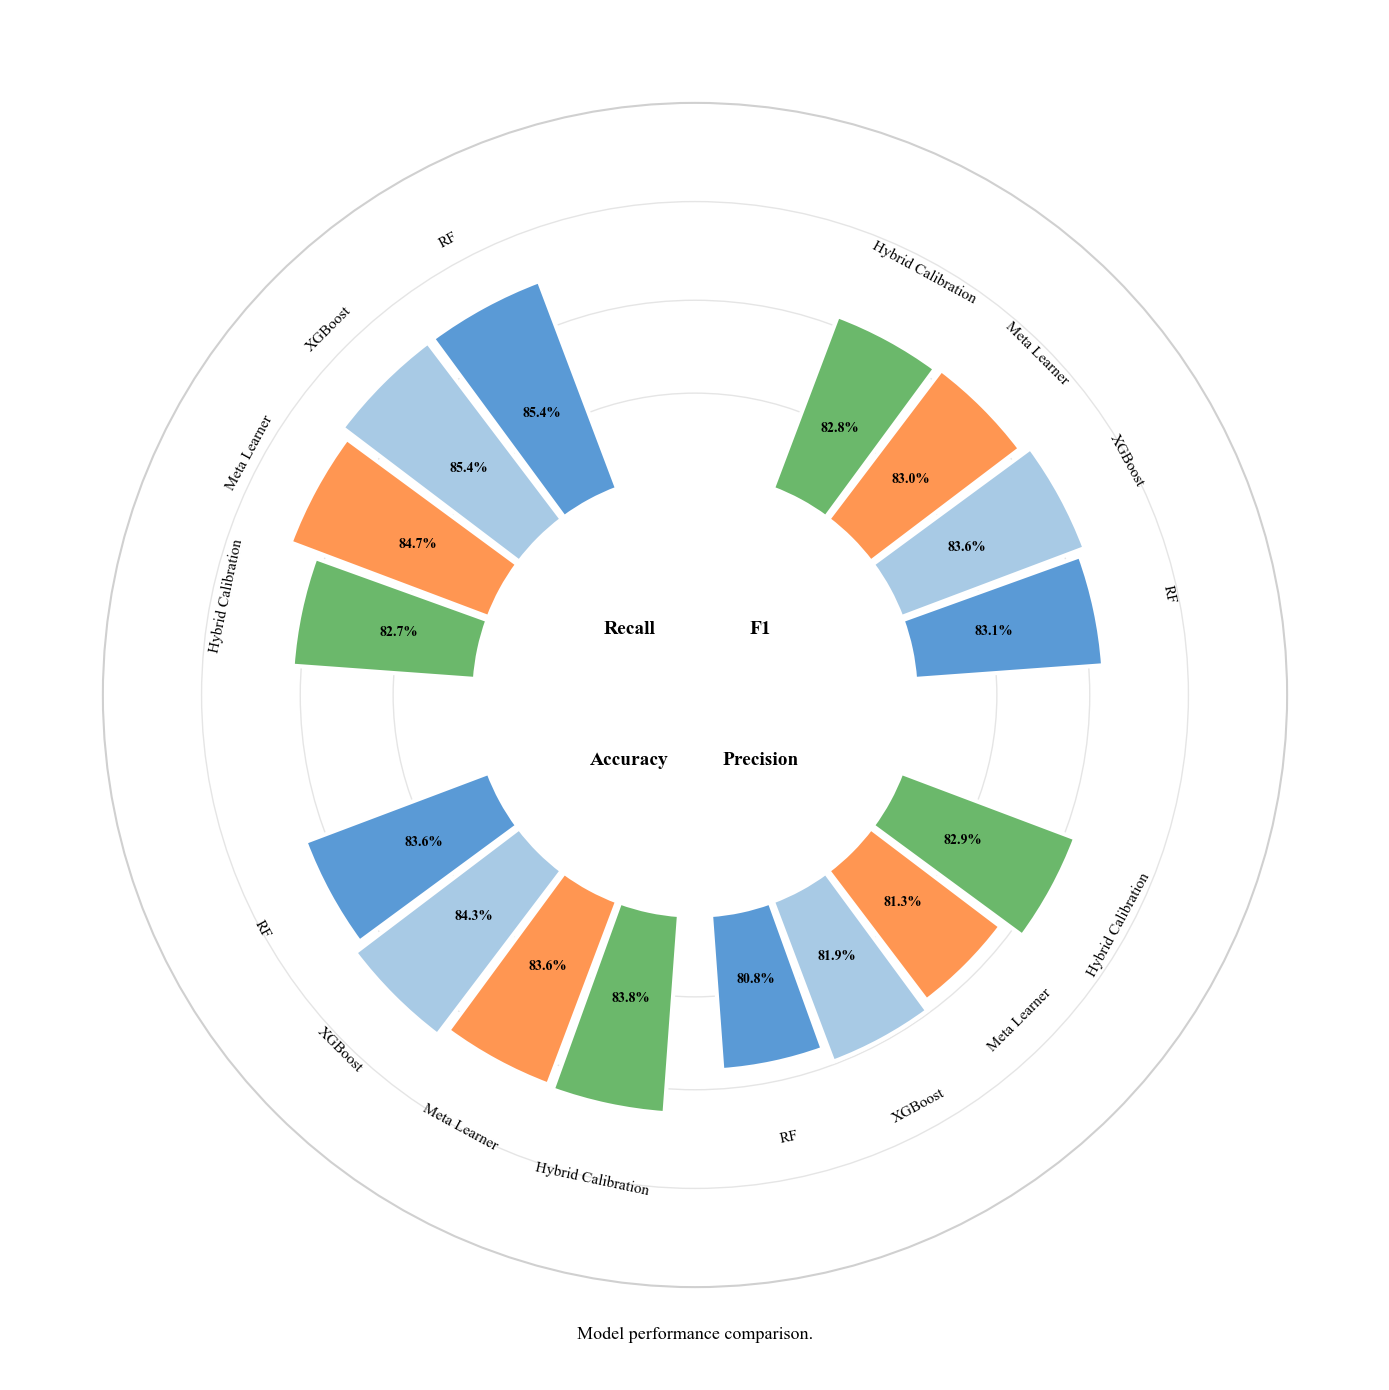

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Exact data with correct ordering for each quadrant
quadrant_data = {
    'Accuracy': {
        'models': ['RF', 'XGBoost', 'Meta Learner', 
                   'Hybrid Calibration'],
        'values': [83.6, 84.3, 83.6, 83.8],
        'colors': ['#5a9ad6', '#a8cae5', '#ff9652', '#6bb86b']
    },
    'Recall': {
        'models': ['RF', 'XGBoost', 'Meta Learner',
                   'Hybrid Calibration'],
        'values': [85.4, 85.4, 84.7, 82.7],
        'colors': ['#5a9ad6', '#a8cae5', '#ff9652', '#6bb86b']
    },
    'F1': {
        'models': ['RF', 'XGBoost', 'Meta Learner',
                   'Hybrid Calibration'],
        'values': [83.1, 83.6, 83.0, 82.8],
        'colors': ['#5a9ad6', '#a8cae5', '#ff9652', '#6bb86b']
    },
    'Precision': {
        'models': ['RF', 'XGBoost', 'Meta Learner',
                   'Hybrid Calibration'],
        'values': [80.8, 81.9, 81.3, 82.9],
        'colors': ['#5a9ad6', '#a8cae5', '#ff9652', '#6bb86b']
    }
}

fig, ax = plt.subplots(figsize=(14, 14), subplot_kw=dict(projection='polar'))

# Larger gaps between quadrants, smaller within
quadrant_gap = np.radians(12)  # Larger gap between quadrants for clear separation
bar_gap_ratio = 0.95  # Small gap between bars (95% width)

# Define quadrants with clearer separation
quadrants = {
    'Accuracy': (np.pi + quadrant_gap, 3*np.pi/2 - quadrant_gap),
    'Recall': (np.pi/2 + quadrant_gap, np.pi - quadrant_gap),
    'F1': (quadrant_gap, np.pi/2 - quadrant_gap),
    'Precision': (3*np.pi/2 + quadrant_gap, 2*np.pi - quadrant_gap)
}

inner_radius = 0.38

# Metric label positions - between quadrants in center
metric_label_positions = {
    'Accuracy': (5*np.pi/4, 0.16),
    'Precision': (7*np.pi/4, 0.16),
    'F1': (np.pi/4, 0.16),
    'Recall': (3*np.pi/4, 0.16)
}

for metric in ['Accuracy', 'F1', 'Precision', 'Recall']:
    models = quadrant_data[metric]['models']
    values = quadrant_data[metric]['values']
    colors = quadrant_data[metric]['colors']
    
    theta_start, theta_end = quadrants[metric]
    n = len(models)
    
    # Reverse for left quadrants (Accuracy, Recall)
    if metric in ['Accuracy', 'Recall']:
        theta_positions = np.linspace(theta_end, theta_start, n, endpoint=False)
        models = models[::-1]
        values = values[::-1]
        colors = colors[::-1]
    else:
        theta_positions = np.linspace(theta_start, theta_end, n, endpoint=False)
    
    # Narrow gaps between bars within quadrant
    width = abs(theta_end - theta_start) / n * bar_gap_ratio
    
    for theta, value, color, model in zip(theta_positions, values, colors, models):
        # Scale bar height
        bar_height = (value - 70) / 25 * 0.62
        
        # Draw bar
        ax.bar(theta, bar_height, width=width, bottom=inner_radius,
               color=color, edgecolor='white', linewidth=3, zorder=2)
        
        # Add percentage
        text_radius = inner_radius + bar_height * 0.45
        ax.text(theta, text_radius, f'{value}%',
               ha='center', va='center', fontsize=10, fontweight='bold', zorder=3)
        
        # Add model name
        name_radius = inner_radius + bar_height + 0.13
        angle_deg = np.degrees(theta)
        
        # Adjust rotation for readability - F1 and Accuracy labels should be upright
        if metric in ['Accuracy', 'F1']:
            # For bottom quadrants, keep text readable
            if 180 < angle_deg <= 360:
                rotation = angle_deg - 270
            else:
                rotation = angle_deg - 90
        else:
            # For top quadrants (Recall, Precision)
            if 90 < angle_deg <= 270:
                rotation = angle_deg - 90
            else:
                rotation = angle_deg + 90
        
        model_display = model.replace('_', '\n')
        ax.text(theta, name_radius, model_display,
               ha='center', va='center', fontsize=11,
               rotation=rotation, rotation_mode='anchor', zorder=3)

# Add metric labels in center between quadrants
for metric, (label_theta, label_r) in metric_label_positions.items():
    ax.text(label_theta, label_r, metric,
           ha='center', va='center', fontsize=14, fontweight='bold', zorder=4)

# Customize plot
ax.set_ylim(0, 1.18)
ax.set_theta_zero_location('E')
ax.set_theta_direction(1)
ax.set_xticks([])
ax.set_yticks([])
ax.spines['polar'].set_visible(False)

# Add circular gridlines
for r in [0.52, 0.68, 0.85]:
    circle = plt.Circle((0, 0), r, fill=False, color='#e5e5e5',
                       linestyle='-', linewidth=1, transform=ax.transData._b, zorder=1)
    ax.add_artist(circle)

# Add outer circle
outer_circle = plt.Circle((0, 0), 1.02, fill=False, color='#d0d0d0',
                         linestyle='-', linewidth=1.5, transform=ax.transData._b, zorder=1)
ax.add_artist(outer_circle)

plt.figtext(0.5, 0.04, 'Model performance comparison.',
           ha='center', fontsize=13)

plt.tight_layout()
plt.show()

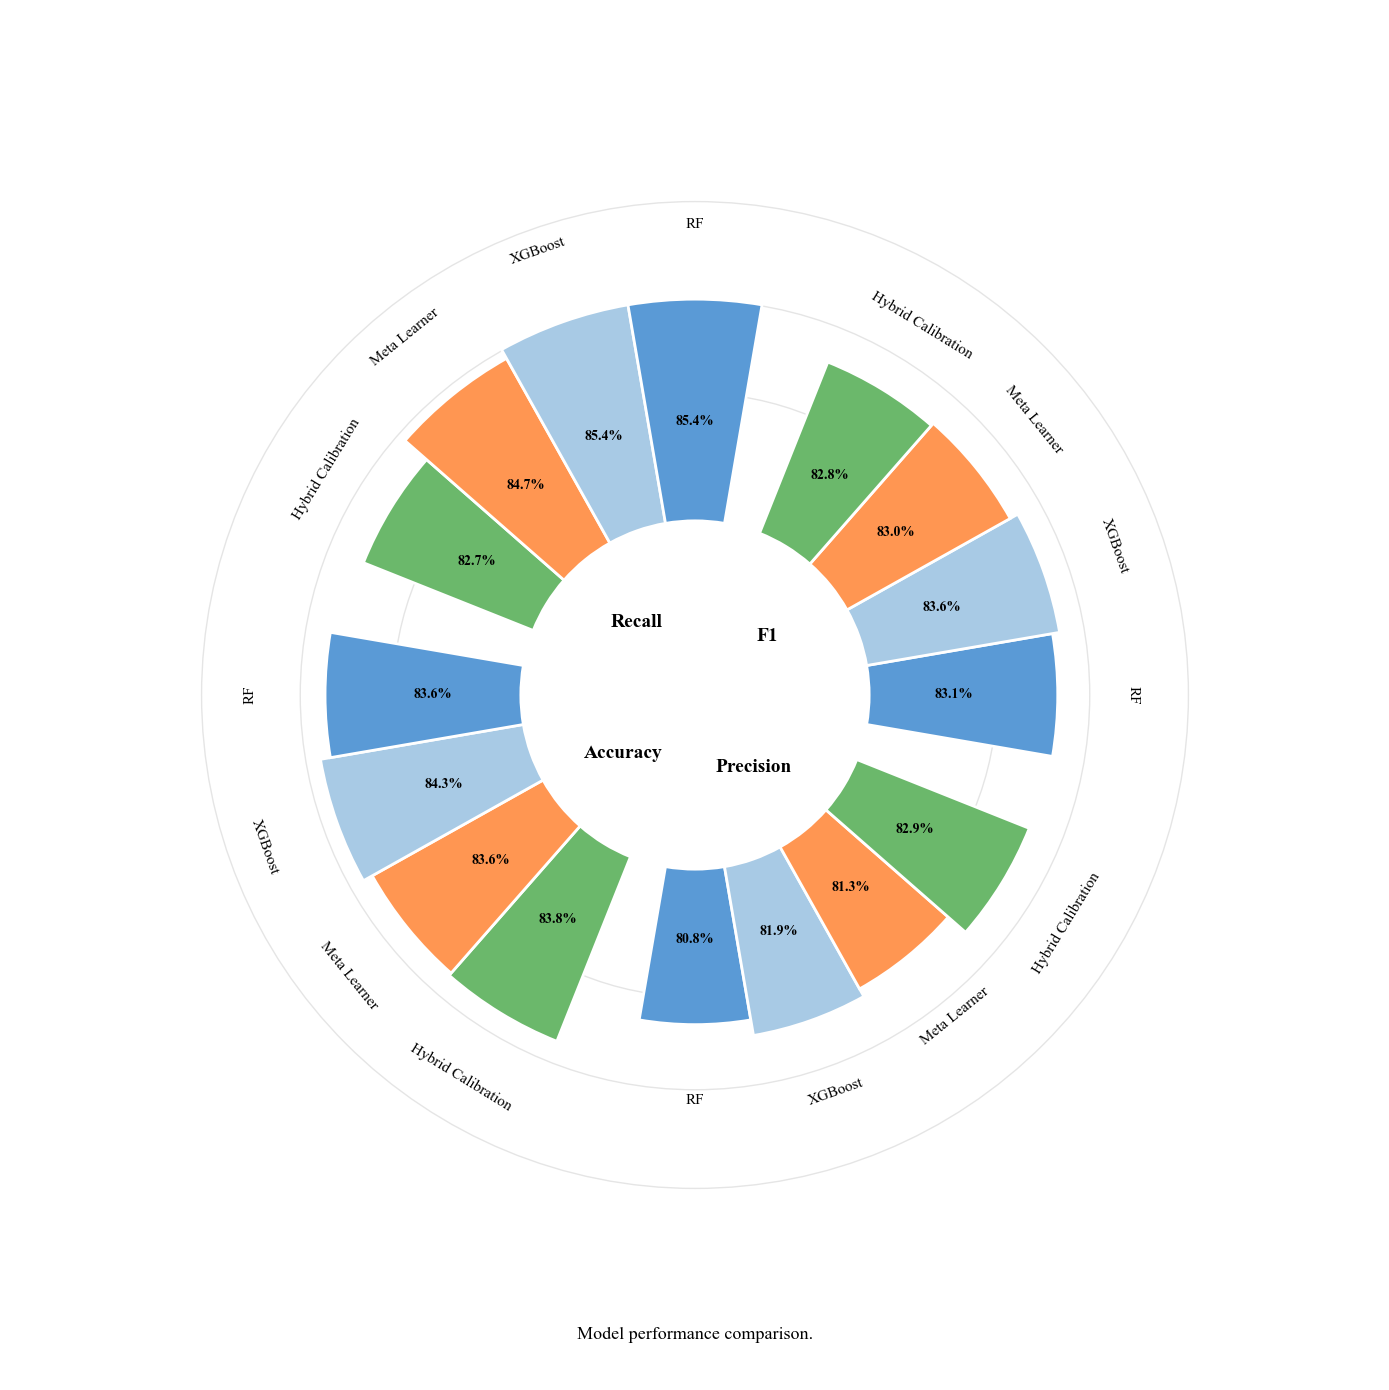

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------
# Data
# ---------------------------
quadrant_data = {
    'Accuracy': {
        'models': ['RF', 'XGBoost', 'Meta Learner', 'Hybrid Calibration'],
        'values': [83.6, 84.3, 83.6, 83.8],
        'colors': ['#5a9ad6', '#a8cae5', '#ff9652', '#6bb86b']
    },
    'Recall': {
        'models': ['RF', 'XGBoost', 'Meta Learner', 'Hybrid Calibration'],
        'values': [85.4, 85.4, 84.7, 82.7],
        'colors': ['#5a9ad6', '#a8cae5', '#ff9652', '#6bb86b']
    },
    'F1': {
        'models': ['RF', 'XGBoost', 'Meta Learner', 'Hybrid Calibration'],
        'values': [83.1, 83.6, 83.0, 82.8],
        'colors': ['#5a9ad6', '#a8cae5', '#ff9652', '#6bb86b']
    },
    'Precision': {
        'models': ['RF', 'XGBoost', 'Meta Learner', 'Hybrid Calibration'],
        'values': [80.8, 81.9, 81.3, 82.9],
        'colors': ['#5a9ad6', '#a8cae5', '#ff9652', '#6bb86b']
    }
}

# ---------------------------
# Figure setup
# ---------------------------
fig, ax = plt.subplots(figsize=(14, 14), subplot_kw=dict(projection='polar'))

# Symmetric quadrant math (equal gaps)
gap = np.deg2rad(12)
full = 2 * np.pi
quad_span = (full - 4 * gap) / 4

# Define evenly spaced quadrants
quad_starts = {
    'F1': 0.0,
    'Recall': quad_span + gap,
    'Accuracy': 2 * quad_span + 2 * gap,
    'Precision': 3 * quad_span + 3 * gap
}
quadrants = {k: (s, s + quad_span) for k, s in quad_starts.items()}

# --- Key fix: no gap between bars ---
bar_gap_ratio = 1.0  # full width, no spacing between bars
inner_radius = 0.30

# Metric label positions (centered)
metric_label_positions = {
    'F1': (quad_starts['F1'] + quad_span / 2, 0.16),
    'Recall': (quad_starts['Recall'] + quad_span / 2, 0.16),
    'Accuracy': (quad_starts['Accuracy'] + quad_span / 2, 0.16),
    'Precision': (quad_starts['Precision'] + quad_span / 2, 0.16),
}

# Draw bars
plot_order = ['Accuracy', 'F1', 'Precision', 'Recall']

for metric in plot_order:
    models = quadrant_data[metric]['models']
    values = quadrant_data[metric]['values']
    colors = quadrant_data[metric]['colors']

    theta_start, theta_end = quadrants[metric]
    n = len(models)
    thetas = np.linspace(theta_start, theta_end, n, endpoint=False)

    # Reverse for left-side quadrants for visual symmetry
    if metric in ['Accuracy', 'Recall']:
        models = models[::-1]
        values = values[::-1]
        colors = colors[::-1]
        thetas = thetas[::-1]

    # Full width between bars (no gap)
    width = (theta_end - theta_start) / n * bar_gap_ratio

    for theta, value, color, model in zip(thetas, values, colors, models):
        bar_height = (value - 70) / 25 * 0.62
        ax.bar(theta, bar_height, width=width, bottom=inner_radius,
               color=color, edgecolor='white', linewidth=2, zorder=2)

        # Value label
        text_r = inner_radius + bar_height * 0.45
        ax.text(theta, text_r, f'{value}%',
                ha='center', va='center', fontsize=10, fontweight='bold', zorder=3)

        # Model name
        name_r = inner_radius + bar_height + 0.13
        ang = np.degrees(theta) % 360
        rotation = ang - 90 if 0 <= ang <= 180 else ang - 270
        ax.text(theta, name_r, model,
                ha='center', va='center', fontsize=11,
                rotation=rotation, rotation_mode='anchor', zorder=3)

# Add metric labels in center
for metric, (th, rr) in metric_label_positions.items():
    ax.text(th, rr, metric, ha='center', va='center',
            fontsize=14, fontweight='bold', zorder=4)

# Styling
ax.set_ylim(0, 1.18)
ax.set_theta_zero_location('E')
ax.set_theta_direction(1)
ax.set_xticks([])
ax.set_yticks([])
ax.spines['polar'].set_visible(False)

# Add circles
for r in [0.52, 0.68, 0.85]:
    ax.add_artist(plt.Circle((0, 0), r, fill=False, color='#e5e5e5',
                             linestyle='-', linewidth=1, transform=ax.transData._b, zorder=1))
'''
ax.add_artist(plt.Circle((0, 0), 1.02, fill=False, color='#d0d0d0',
                         linestyle='-', linewidth=1.5, transform=ax.transData._b, zorder=1))
'''
plt.figtext(0.5, 0.04, 'Model performance comparison.', ha='center', fontsize=13)
plt.tight_layout()
plt.savefig("model_performance.png", dpi=600, bbox_inches='tight')

plt.show()




In [36]:
# ============================================================
# Subgroup Performance Analysis with Hybrid Calibrated Model
# Reuses: X_train_enc, X_test_enc, y_train, y_test, X_test (RAW)
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    precision_recall_curve, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss
)

# ---------------------------
# 0) Guardrails / assumptions
# ---------------------------
# - X_train_enc, X_test_enc are encoded DataFrames aligned with X_train/X_test
# - y_train, y_test are 1D arrays/Series with 0/1 labels
# - X_test is the RAW (unencoded) DataFrame for grouping
# If your variables are differently named, map them before running.

y_train_arr = np.asarray(y_train).astype(int).ravel()
y_test_arr  = np.asarray(y_test).astype(int).ravel()

# Optional: sanity alignment (only if both are DataFrames)
if hasattr(X_test_enc, "index") and hasattr(X_test, "index"):
    assert len(X_test_enc) == len(X_test), "Encoded and raw X_test lengths differ."
    # If indices differ, reindex raw to encoded
    if not (X_test_enc.index.equals(X_test.index)):
        X_test = X_test.loc[X_test_enc.index]
        print("[info] Aligned X_test to X_test_enc indices.")

# ---------------------------
# 1) Fit the Hybrid Calibrated model
#    - Calibrated RF
#    - Calibrated XGBoost (if available)
#    - Average calibrated probabilities
# ---------------------------
def fit_hybrid_calibrated(X_tr, y_tr, cv=3, random_state=42):
    # --- Calibrated Random Forest ---
    rf = RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        n_jobs=-1,
        random_state=random_state
    )
    try:
        cal_rf = CalibratedClassifierCV(estimator=rf, method="isotonic", cv=cv)
    except TypeError:
        cal_rf = CalibratedClassifierCV(base_estimator=rf, method="isotonic", cv=cv)
    cal_rf.fit(X_tr, y_tr)

    # --- Calibrated XGBoost (optional if installed) ---
    cal_xgb = None
    try:
        from xgboost import XGBClassifier
        neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
        xgb = XGBClassifier(
            n_estimators=600, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
            tree_method="hist", eval_metric="logloss",
            scale_pos_weight=float(neg / max(pos, 1)),
            random_state=random_state, n_jobs=-1
        )
        try:
            cal_xgb = CalibratedClassifierCV(estimator=xgb, method="isotonic", cv=cv)
        except TypeError:
            cal_xgb = CalibratedClassifierCV(base_estimator=xgb, method="isotonic", cv=cv)
        cal_xgb.fit(X_tr, y_tr)
        print("[info] Using Hybrid = Calibrated RF + Calibrated XGBoost (averaged).")
    except Exception as e:
        print(f"[warn] XGBoost not available ({e}); using Calibrated RF only.")

    def predict_proba(X):
        p_rf = cal_rf.predict_proba(X)[:, 1]
        if cal_xgb is not None:
            p_xgb = cal_xgb.predict_proba(X)[:, 1]
            return (p_rf + p_xgb) / 2.0
        return p_rf

    return {"rf": cal_rf, "xgb": cal_xgb, "predict_proba": predict_proba}

hyb = fit_hybrid_calibrated(X_train_enc, y_train_arr, cv=3, random_state=42)

# ---------------------------
# 2) Pick a single global threshold on the TEST set (F1+ optimal)
# ---------------------------
proba_test = hyb["predict_proba"](X_test_enc)

prec, rec, thr = precision_recall_curve(y_test_arr, proba_test)
f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_idx = int(np.nanargmax(f1))
GLOBAL_THR = float(thr[best_idx])

print(f"[info] Global threshold (F1-opt) = {GLOBAL_THR:.3f}")
print(f"[info] Overall ROC-AUC = {roc_auc_score(y_test_arr, proba_test):.4f} | "
      f"Brier = {brier_score_loss(y_test_arr, proba_test):.4f}")

# ---------------------------
# 3) Build evaluation DataFrame aligned by row
# ---------------------------
df_eval = X_test.copy()  # RAW features for grouping
df_eval["y_true"] = y_test_arr
df_eval["proba"]  = proba_test
df_eval["y_pred"] = (df_eval["proba"] >= GLOBAL_THR).astype(int)

# ---------------------------
# 4) Utility to compute metrics on a slice
# ---------------------------
def slice_metrics(df):
    return {
        "support":  int(len(df)),
        "precision": precision_score(df["y_true"], df["y_pred"], zero_division=0),
        "recall":    recall_score(df["y_true"], df["y_pred"], zero_division=0),
        "f1":        f1_score(df["y_true"], df["y_pred"], zero_division=0),
        "brier":     brier_score_loss(df["y_true"], df["proba"]),
    }

# ---------------------------
# 5) Subgroup definitions (EDIT column names to match yours)
# ---------------------------
SUBGROUP_COLS = {
    "sex":          "SEXNAME",        # e.g., 'Male', 'Female', 'Unknown'
    "person_type":  "PER_TYPENAME",   # e.g., Driver/Passenger/Pedestrian/Cyclist
    "seat_position":"SEAT_POSNAME",   # seating position
    "rural_urban":  "RUR_URBNAME",    # Rural/Urban designation
    "person_type":  "PER_TYPNAME",    # Rural/Urban designation

}

# Clean subgroup columns
for col in SUBGROUP_COLS.values():
    if col in df_eval.columns:
        df_eval[col] = df_eval[col].fillna("Unknown").astype(str)
    else:
        print(f"[warn] Subgroup column not found: {col}")

# ---------------------------
# 6) Evaluate per subgroup with the SAME global threshold
# ---------------------------
MIN_SUPPORT = 200  # skip tiny groups to avoid noisy metrics
rows = []

for nice_name, col in SUBGROUP_COLS.items():
    if col not in df_eval.columns:
        continue
    for level, df_sub in df_eval.groupby(col):
        if len(df_sub) < MIN_SUPPORT:
            continue
        m = slice_metrics(df_sub)
        rows.append({
            "subgroup": nice_name,
            "level":    str(level),
            "support":  m["support"],
            "precision": round(m["precision"], 4),
            "recall":    round(m["recall"], 4),
            "f1":        round(m["f1"], 4),
            "brier":     round(m["brier"], 4),
        })

subgroup_df = pd.DataFrame(rows).sort_values(
    by=["subgroup", "support"], ascending=[True, False]
).reset_index(drop=True)

print("\n=== Subgroup Performance (Hybrid Calibrated, fixed global threshold) ===")
print(subgroup_df.head(20).to_string(index=False))

# Optionally save full table
# subgroup_df.to_csv("subgroup_performance_hybrid_calibrated.csv", index=False)

# ---------------------------
# 7) Overall metrics at the fixed threshold (sanity check)
# ---------------------------
overall = slice_metrics(df_eval)
print("\n[Overall @ global threshold]")
print(f"  Support : {overall['support']}")
print(f"  Precision: {overall['precision']:.4f}")
print(f"  Recall   : {overall['recall']:.4f}")
print(f"  F1       : {overall['f1']:.4f}")
print(f"  Brier    : {overall['brier']:.4f}")


[info] Using Hybrid = Calibrated RF + Calibrated XGBoost (averaged).
[info] Global threshold (F1-opt) = 0.506
[info] Overall ROC-AUC = 0.9150 | Brier = 0.1295

=== Subgroup Performance (Hybrid Calibrated, fixed global threshold) ===
     subgroup                                               level  support  precision  recall     f1  brier
  person_type              Driver of a Motor Vehicle In-Transport    92896     0.8153  0.8517 0.8331 0.1286
  person_type           Passenger of a Motor Vehicle In-Transport    40369     0.6658  0.5682 0.6131 0.1596
  person_type                                          Pedestrian    12461     0.9516  0.9989 0.9747 0.0525
  person_type                                           Bicyclist     1799     0.9750  1.0000 0.9873 0.0361
  person_type       Occupant of a Motor Vehicle Not In- Transport      620     0.6290  0.4062 0.4937 0.1283
  rural_urban                                               Urban    88003     0.8368  0.8438 0.8403 0.1164
  rural_urb